# 분석 목표
이 노트북은 동일한 급탕 사용 스케줄과 실외 온도 조건에서 GasBoiler와 AirSourceHeatPumpBoiler의 동적 시뮬레이션을 수행하고, 각 나라의 현재 전력 믹스를 기반으로 Well-to-tap 분석을 통해 CO2 배출량, Primary energy use, 엑서지 효율, 에너지 효율을 타임시리즈로 분석합니다.

- 동적 시뮬레이션 기반 타임시리즈 분석
- 나라별 전력 믹스에 따른 CO2 배출량 비교
- Primary Energy 사용량 비교
- 엑서지 효율 및 에너지 효율 비교
- 일일 적분값 비교

# 1. Ready

## 1.1 Import library

In [3]:
%load_ext autoreload
%autoreload 2

# Import libraries
import sys
import os

# Add paths
sys.path.append('../../src')  # enex_analysis 모듈 경로
sys.path.append('.')  # 현재 디렉토리 (grid_mix_analysis, well_to_tap)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import dartwork_mpl as dm
import enex_analysis as enex
import matplotlib.ticker as ticker
from tqdm import tqdm
import matplotlib.gridspec as gridspec
import CoolProp as CP
import cv2

# Apply dartwork_mpl style
dm.style.stack(['dmpl_light'])

# Import simulation modules
from enex_analysis.GasBoiler import GasBoiler
from enex_analysis.AirSourceHeatPumpBoiler import AirSourceHeatPumpBoiler

# constant
from enex_analysis.constants import (
    c_a,
    c_w,
    rho_a,
    rho_w,
)

# Import grid mix analysis modules
from grid_mix_analysis import (
    COUNTRY_GRID_MIX,
    COUNTRY_ANNUAL_AVG_TEMP,
    DEFAULT_TECH_PARAMS,
    KOREA_TECH_PARAMS,
    PowerGenerationMix,
    calculate_grid_primary_energy_factor,
    calculate_grid_co2_factor,
    get_country_renewable_tech_mix
)

from enex_analysis.enex_functions import *

# Import well-to-tap analysis
from well_to_tap import WellToTapAnalyzer

print("Libraries imported successfully!")


Libraries imported successfully!


## 1.2 font 

In [4]:
## Fontsize 지정
plt.rcParams['font.size'] = 9

fs = {
    'label': dm.fs(0),
    'tick': dm.fs(-1.0),
    'legend': dm.fs(-1.5),
    'subtitle': dm.fs(-0.5),
    'cbar_tick': dm.fs(-1.5),
    'cbar_label': dm.fs(-1.5),
    'cbar_title': dm.fs(-1),
    'setpoint': dm.fs(-1),
    'text': dm.fs(-2.0),
            }

pad = {
    'label': 6,
    'tick': 5,
}

LW = np.arange(0.25, 3.0, 0.25)


# 2. 시뮬레이션 사전 준비

동일한 조건에서 GB와 HPB를 비교하기 위한 공통 파라미터를 설정합니다.

## 2.1 Hot water use schedule

In [32]:
# 시뮬레이션 파라미터 설정
simulation_period_sec = 24 * enex.h2s  # 24시간
dt_s = 60  # 60 초
tN = int(simulation_period_sec / dt_s) # time step number
time_s = np.arange(tN + 1) * dt_s
time_h = time_s * enex.s2h

T_serv_w = 40.0  # 서비스 급탕 온도 [°C]
T_sup_w = 15.0   # 급수(상수도) 온도 [°C]
T0 = 10.0         # 기준 온도 [°C]

dV_w_serv_m3s = 0.00002
# 급탕 사용 스케줄 (동일한 패턴 사용)
# https://gemini.google.com/share/55648c0c6801
schedule_entries = [
        # --- 0:00 - 6:00 (사용 0) ---
        # --- 아침 피크 ---
        ("6:00", "6:30", 0.2),
        ("6:30", "7:00", 0.3),
        ("7:00", "7:20", 0.6),  # <--- Peak (1.0)
        ("7:20", "7:30", 0.8),  # <--- Peak (1.0)
        ("7:30", "8:00", 0.4),
        ("8:00", "8:30", 0.2),
        ("8:30", "9:00", 0.2),
        
        # --- 주간 (최소 0.05, 점심 피크) ---
        ("11:30", "12:00", 0.2), # 점심 준비/손 씻기
        ("12:00", "12:30", 0.4), # 식사/설거지
        ("12:30", "13:00", 0.3), # 설거지/양치
        ("13:00", "13:30", 0.2), # 마무리
        
        # --- 저녁 피크 ---
        ("17:00", "17:30", 0.2),
        ("17:30", "18:00", 0.3),
        ("18:00", "18:30", 0.4),
        ("18:30", "18:50", 0.7),
        ("18:50", "19:10", 1.0),
        ("19:00", "19:30", 0.8),
        ("19:30", "20:00", 0.4),
        
        # --- 저녁 (감소) ---
        ("20:00", "20:30", 0.3),
        ("20:30", "21:00", 0.2),
        ("21:00", "21:30", 0.1),
        # --- 22:00 - 24:00 (사용 0) ---
    ]

# schedule_entries=[
# #---아침피크---
# #---0:00-6:00(사용0)---
# ("7:30","7:40",0.05),
# ("7:40","7:45",0.1),
# ("8:00","8:01",0.3),#<---Peak(1.0)
# ("8:00","8:05",0.6),#<---Peak(1.0)
# ("8:05","8:10",0.2),
# ("7:10","7:30",0.05),
# ("7:30","8:00",0.01),
# #---주간(최소0.05,점심피크)---
# ("9:00","11:30",0.0),#2.5시간(5개구간)
# ("11:30","12:00",0.05),#점심준비/손씻기
# #---저녁(감소)---
# ("17:30","18:00",0.05),
# ("18:00","18:30",0.1),
# ("18:50","19:00",0.2),#<---Peak(1.0)
# ("19:00","19:05",0.8),#<---Peak(1.0)
# ("19:05","19:30",0.12),
# ("19:30","20:00",0.1),
# ("20:30","21:00",0.01),
# #---22:00-24:00(사용0)---
# ]

calc_total_water_use_from_schedule(schedule_entries, dV_w_serv_m3s)

 Start ~    End | Ratio | Liters
-----------------------------------
  6:00 ~   6:30 |  0.20 |    7.2 L
  6:30 ~   7:00 |  0.30 |   10.8 L
  7:00 ~   7:20 |  0.60 |   14.4 L
  7:20 ~   7:30 |  0.80 |    9.6 L
  7:30 ~   8:00 |  0.40 |   14.4 L
  8:00 ~   8:30 |  0.20 |    7.2 L
  8:30 ~   9:00 |  0.20 |    7.2 L
 11:30 ~  12:00 |  0.20 |    7.2 L
 12:00 ~  12:30 |  0.40 |   14.4 L
 12:30 ~  13:00 |  0.30 |   10.8 L
 13:00 ~  13:30 |  0.20 |    7.2 L
 17:00 ~  17:30 |  0.20 |    7.2 L
 17:30 ~  18:00 |  0.30 |   10.8 L
 18:00 ~  18:30 |  0.40 |   14.4 L
 18:30 ~  18:50 |  0.70 |   16.8 L
 18:50 ~  19:10 |  1.00 |   24.0 L
 19:00 ~  19:30 |  0.80 |   28.8 L
 19:30 ~  20:00 |  0.40 |   14.4 L
 20:00 ~  20:30 |  0.30 |   10.8 L
 20:30 ~  21:00 |  0.20 |    7.2 L
 21:00 ~  21:30 |  0.10 |    3.6 L
-----------------------------------
Total daily water use: 248.40 Liters


248.40000000000003

## 2.2 Selection of countries for analysis

각 나라의 전력 믹스를 기반으로 PEF, CO2 계수, 엑서지 효율을 계산하고 타임시리즈 분석을 수행합니다.

In [23]:
# 분석할 나라 선택 (다양한 재생에너지 비율을 가진 나라들)
selected_countries = [
    'South Korea',  # 재생에너지 11%
    # 'China',        # 재생에너지 37%
    # 'Germany',      # 재생에너지 56%
    # 'Norway',       # 재생에너지 99%
    # 'France',       # 원자력 중심 (재생 27%, 원자력 69%)
]

## 2.3 System setting

In [ ]:
gb = GasBoiler(
    eta_comb=0.9,
    T_serv_w=T_serv_w,
    T_sup_w=T_sup_w,
    T_comb_setpoint=60.0,
    dV_w_serv_m3s=0.000333  # 최대 급탕 유량 [m³/s]
)

hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = 'R134a',
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 500.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 1500.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 4,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 200.0,   # 실외기 설계 정압 [Pa]
    # dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_setpoint    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 20000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = dV_w_serv_m3s,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.005,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)

## 2.3.1 Fan Model Visualization

In [25]:

# # Fan 모델 파라미터 추출
# dV_ou_design = hpb.dV_ou_design  # 설계 풍량 [m³/s]
# fan_power_ou_design = hpb.fan_power_ou_design  # 설계 전력 [W]
# dP_ou_design = hpb.dP_ou_design  # 설계 정압 [Pa]
# eta_fan_ou_design = hpb.eta_fan_ou_design  # 설계 효율 [-]
# vsd_coeffs = hpb.vsd_coeffs_ou  # VSD 계수
# E_fan_ou_design = dP_ou_design * dV_ou_design / eta_fan_ou_design
# # 풍량 범위 설정 (0 ~ 설계 풍량의 1.2배)
# dV_range = np.linspace(0.01, dV_ou_design * 1.2, 200)  # 0.01부터 시작 (0으로 나누기 방지)

# # VSD 곡선 계산
# from enex_analysis.enex_functions import calc_fan_power_from_dV_fan

# fan_powers = []
# fan_efficiencies = []

# for dV in dV_range:
#     # 팬 전력 계산
#     E_fan = calc_fan_power_from_dV_fan(
#         dV_fan=dV,
#         fan_params=hpb.fan_params_ou,
#         vsd_coeffs=vsd_coeffs
#     )
#     fan_powers.append(E_fan * enex.W2kW)  # [kW]로 변환
    
#     # 팬 효율 계산: eta_fan = eta_fan_design * dV_fan / E_fan
#     if E_fan > 0:
#         fan_eff = hpb.dP_ou_design * dV / (E_fan)
#     else:
#         fan_eff = 0.0
#     fan_efficiencies.append(fan_eff)

# fan_powers = np.array(fan_powers)
# fan_efficiencies = np.array(fan_efficiencies)

# # 그래프 생성: 1열 twin axis
# fig, ax_power = plt.subplots(1, 1, figsize=(dm.cm2in(8.5), dm.cm2in(5)))
# ax_power.set_facecolor('none')

# # 왼쪽 y축: 팬 전력
# power_plot = ax_power.plot(
#     dV_range, fan_powers,
#     label='Fan power',
#     color='oc.red5', linewidth=dm.lw(0)
# )
# ax_power.set_xlabel('Volumetric flow rate [m³/s]', fontsize=fs['label'], labelpad=pad['label'])
# ax_power.set_ylabel('Fan power [kW]', fontsize=fs['label'], labelpad=pad['label'], color='oc.red6')
# ax_power.tick_params(axis='x', which='major', labelsize=fs['tick'], pad=pad['tick'])
# ax_power.tick_params(axis='y', which='major', labelsize=fs['tick'], pad=pad['tick'], labelcolor='oc.red6')
# ax_power.grid(True, alpha=0.3)

# # 오른쪽 y축: 팬 효율
# ax_eff = ax_power.twinx()
# ax_eff.set_facecolor('none')
# eff_plot = ax_eff.plot(
#     dV_range, fan_efficiencies,
#     label='Fan efficiency',
#     color='oc.orange5', linewidth=dm.lw(0)
# )
# ax_eff.set_ylabel('Fan efficiency [-]', fontsize=fs['label'], labelpad=pad['label'], color='oc.orange6')
# ax_eff.tick_params(axis='y', which='major', labelsize=fs['tick'], pad=pad['tick'], labelcolor='oc.orange6')
# ax_eff.grid(False)

# # 범례 (두 축 모두)
# lines1, labels1 = ax_power.get_legend_handles_labels()
# lines2, labels2 = ax_eff.get_legend_handles_labels()
# ax_power.legend(
#     lines1 + lines2, labels1 + labels2,
#     loc='upper left',
#     fontsize=fs['legend'],
#     bbox_to_anchor=(0.0, 1),
#     handlelength=1.5,
#     labelspacing=0.5,
#     handletextpad=0.5,
#     columnspacing=2,
#     ncol=1,
# )

# # 설계점 표시
# ax_power.axvline(x=dV_ou_design, color='oc.blue5', linestyle='--', linewidth=dm.lw(1), alpha=0.5, label='Design point')
# ax_power.axhline(y=fan_power_ou_design * enex.W2kW, color='oc.blue5', linestyle='--', linewidth=dm.lw(1), alpha=0.5)

# dm.simple_layout(fig, margins=(0.1, 0.1, 0.05, 0.05), bbox=(0, 1, 0.015, 1), verbose=False)
# plt.savefig('../figure/fan_model_vsd_curve.png', dpi=600)
# dm.save_and_show(fig, size=600)
# print(E_fan_ou_design)


## 2.4 국가별 CO2 및 PEF 설정

In [55]:
elec_co2_factor = {}
elec_primary_energy_factor = {}

for country in selected_countries:
    mix_dict = COUNTRY_GRID_MIX[country]
    mix = PowerGenerationMix(
        coal=mix_dict['coal'],
        gas=mix_dict['gas'],
        nuclear=mix_dict['nuclear'],
        renewable=mix_dict['renewable'],
        oil=mix_dict.get('oil', 0.0),
        other=mix_dict.get('other', 0.0)
    )
    elec_co2_factor[country] = calculate_grid_co2_factor(mix =mix, tech_params =DEFAULT_TECH_PARAMS, country_name =country)
    elec_primary_energy_factor[country] = calculate_grid_primary_energy_factor(mix = mix, tech_params = DEFAULT_TECH_PARAMS, country_name = country)


In [56]:
print('Gas primary energy factor:', KOREA_TECH_PARAMS['gas'].primary_energy_factor)
print('Gas CO2 factor:', KOREA_TECH_PARAMS['gas'].co2_emission_factor)
print('Electricity primary energy factor (South Korea):', elec_primary_energy_factor['South Korea'])
print('Electricity CO2 factor (South Korea):', elec_co2_factor['South Korea'])


Gas primary energy factor: 1.1
Gas CO2 factor: 0.202
Electricity primary energy factor (South Korea): 2.23604
Electricity CO2 factor (South Korea): 0.40512290000000006


# 3. 분석 함수 및 실행

나라별 전력 믹스를 기반으로 분석 함수를 구현하고 선택된 나라들에 대한 분석을 수행합니다.


## 3.1 Simulation


In [33]:
# 각 나라별 분석 수행
result_dir = '../result'
country_results = {}
for country in selected_countries:
    print(f"\n{country} 분석 중...")
    if country not in COUNTRY_GRID_MIX:
        raise ValueError(f"Country '{country}' not found in COUNTRY_GRID_MIX")
    
    if country not in COUNTRY_ANNUAL_AVG_TEMP:
        raise ValueError(f"Country '{country}' not found in COUNTRY_ANNUAL_AVG_TEMP")
    
    # 국가별 외기온도 가져오기
    tN = int(simulation_period_sec / dt_s)
    T0_schedule = [10] * tN
    
    # 파일명 생성 (공백을 언더스코어로 변환)
    country_safe = country.replace(' ', '_')
    gb_csv_path  = f"{result_dir}/gb_{country_safe}.csv"
    hpb_csv_path = f"{result_dir}/hpb_{country_safe}.csv"
    
    # GB 시뮬레이션 실행 및 CSV 저장
    gb_results = gb.analyze_dynamic(
        simulation_period_sec = simulation_period_sec,
        dt_s                  = dt_s,
        schedule_entries      = schedule_entries,
        T0_schedule           = T0_schedule,
        result_save_csv_path  = gb_csv_path
    )
    
    # HPB 시뮬레이션 실행 및 CSV 저장
    hpb_results = hpb.analyze_dynamic(
        simulation_period_sec = simulation_period_sec,
        dt_s                  = dt_s,
        T_tank_w_init_C       = 60,
        schedule_entries      = schedule_entries,
        T0_schedule           = T0_schedule,
        result_save_csv_path  = hpb_csv_path
    )


South Korea 분석 중...


ASHPB Simulating: 100%|██████████| 1440/1440 [00:25<00:00, 56.49it/s] 


## 3.2 Data organization

In [34]:
country_results = {}
for country in selected_countries:
    country_results[country] = {}
    country_results[country]['gb_results'] = pd.read_csv(f'../result/gb_{country.replace(" ", "_")}.csv')
    country_results[country]['hpb_results'] = pd.read_csv(f'../result/hpb_{country.replace(" ", "_")}.csv')

# 4. 시각화

시뮬레이션 결과를 타임시리즈 플롯, 일일 적분값 비교, 요약 테이블로 시각화합니다.


## 4.1 급탕 스케줄
피크가 상당히 과소평가되어있음.

In [43]:
# ===================== 사용자 입력(수정 지점) =====================
# 시뮬레이션 파라미터 섹션(1-53행) 데이터만 사용하여 온수 사용량 플롯

# X: 시간축, Y: 온수 사용량 (L/min) 직접 생성
X = time_h[:-1]  # 시간 [h], 길이 = 타임스텝 개수
Y1 = country_results['South Korea']['gb_results']['dV_w_serv [m3/s]'] * enex.m32L / enex.s2m

X_LABEL = 'Hour of day [h]'
Y_LABEL = 'Hot water usage [L/min]'

xmin1, xmax1, xint1, xmar1 = 0, 24, 4, 0
ymin1, ymax1, yint1, ymar1 = 0, 24, 4, 0
color_ax1 = 'oc.blue'
# ===============================================================

fig, ax1 = plt.subplots(1,1, figsize=(dm.cm2in(9), dm.cm2in(5)))

ax1.plot(X, Y1, label='', linewidth=LW[2], color=color_ax1 + '4')

ax1.set_xlabel(X_LABEL, fontsize=fs['label'], labelpad=pad['label'])
ax1.set_ylabel(Y_LABEL, fontsize=fs['label'], labelpad=pad['label'])

ax1.set_xlim(xmin1 - xmar1, xmax1 + xmar1)
ax1.set_ylim(ymin1 - 0.2, ymax1 + ymar1)

ax1.set_xticks(np.arange(xmin1, xmax1*1.001, xint1))
ax1.set_yticks(np.arange(ymin1, ymax1*1.001, yint1))

ax1.tick_params(labelsize=fs['tick'], which='major', length=2.5, width=0.3, pad=pad['tick'])
ax1.tick_params(labelsize=fs['tick'], which='minor', length=1.25, width=0.3, pad=pad['tick'])

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(1))

ax1.tick_params(axis='y', labelsize=fs['tick'], which='major', pad=pad['tick'],)
ax1.tick_params(axis='y', labelsize=fs['tick'], which='minor', pad=pad['tick'],)

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles, labels, loc='upper center', fontsize=fs['legend'], bbox_to_anchor=(0.5, 1.1), ncols=5,
          handlelength=1.5, columnspacing=2, labelspacing=0.5)

dm.simple_layout(fig, bbox=[0, 1, 0.02, 1.0], margins=[0.05, 0.05, 0.05, 0.0])
plt.savefig('../figure/water_use_schedule_ashpb.svg', dpi=900, transparent=True)
plt.savefig('../figure/water_use_schedule_ashpb.png', dpi=900)
dm.save_and_show(fig)


## 4.2 Country comparision

## 4.2.1 CO2 emission

## 4.2.2 Tank water temperature and System COP and power

In [44]:
# ====== Plot Limit & Tick 설정 변수(최상단 지정 참고, 재사용) ======
# X축/시간/온도/전력/cop 등 모든 limit, tick, style 변수 재활용
X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT, X_TEMP_MAR = 0, 24, 4, 0
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT, Y_TEMP_MAR = 0, 80, 10, 0
Y_POWER_MIN, Y_POWER_MAX, Y_POWER_INT, Y_POWER_MAR = 0, 6, 1, 0
Y_COP_MIN, Y_COP_MAX, Y_COP_INT, Y_COP_MAR = 2, 2.6, 0.1, 0

X_LIM_TEMP = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP = (Y_TEMP_MIN, Y_TEMP_MAX)
Y_LIM_POWER = (Y_POWER_MIN, Y_POWER_MAX)
Y_LIM_COP = (Y_COP_MIN, Y_COP_MAX)

HOTWATER_YMIN = 0
HOTWATER_YMAX = 8
HOTWATER_YINT = 1

XTICKS_TEMP = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)
XTICKS_POWER = XTICKS_TEMP
YTICKS_POWER = np.arange(Y_POWER_MIN, Y_POWER_MAX + Y_POWER_INT / 2, Y_POWER_INT)
XTICKS_COP = XTICKS_TEMP
YTICKS_COP = np.arange(Y_COP_MIN, Y_COP_MAX + Y_COP_INT / 2, Y_COP_INT)

ss = 2
ss_leg_r = 3

fc = "#F9F8F6"

# 데이터 준비
df = country_results['South Korea']['hpb_results']
time_h_full = time_h[:-1] if len(df) == len(time_h[:-1]) else np.arange(len(df)) * dt_s / 3600

fan_power_full = df['E_fan_ou [W]'] * enex.W2kW
comp_power_full = df['E_cmp [W]'] * enex.W2kW
cop_full = df['cop [-]']
fan_power_masked = fan_power_full.mask(fan_power_full == 0, np.nan)
comp_power_masked = comp_power_full.mask(comp_power_full == 0, np.nan)
cop_masked = cop_full.mask(cop_full == 0, np.nan)

# Figure: 1행 2열, 각 ax 디자인 통일
fig, axes = plt.subplots(1, 2, figsize=(dm.cm2in(17), dm.cm2in(5)),facecolor=fc)
ax_temp, ax_power = axes

# --- 1열: 저탕조 온도 + 외기온도 ---
ax_temp.set_facecolor('none')
ax_temp.plot(
    time_h_full, df['T_tank_w [°C]'],
    label='Tank water',
    color='oc.red5', linewidth=dm.lw(0)
)
ax_temp.plot(
    time_h_full, df['T0 [°C]'],
    label='Outdoor air',
    color='oc.orange5', linewidth=dm.lw(0)
)
ax_temp.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_temp.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=pad['label'])
ax_temp.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_temp.set_xticks(XTICKS_TEMP)
ax_temp.set_yticks(YTICKS_TEMP)
ax_temp.set_xlim(X_LIM_TEMP)
ax_temp.set_ylim(Y_LIM_TEMP)
ax_temp.legend(loc='upper left',
                fontsize=fs['legend'],
                bbox_to_anchor=(0.0, 1), 
                handlelength=1.5, 
                labelspacing=0.5,       
                handletextpad=0.5,          
                columnspacing=2,           
                ncol=2,) 
# 범례 열 수)
ax_temp.grid(True, alpha=0.3)

# ====== Twin axis for hot water usage schedule (always full 24h): area plot로 수정됨 ======
ax_temp.set_zorder(2)
ax_hw = ax_temp.twinx()
ax_hw.set_zorder(1)
ax_hw.set_facecolor('none')
ax_hw.spines['right'].set_visible(True)

# 현재 진행 구간: blue2로 오버레이 (alpha=0.5)
ax_hw.fill_between(time_h_full, df['dV_w_serv [m3/s]'] * enex.m32L / enex.s2m, 0, color='oc.blue1', alpha=0.5, zorder=-1, linewidth=0)

# 필요하면 outline 또는 보조선도 추가 가능
# ax_hw.plot(time_h_full, Y_HOTWATER, color=COLOR_HOTWATER_BG + '4', linewidth=LW[2], zorder=0)
# ax_hw.plot(x, Y_HOTWATER, color=COLOR_HOTWATER + '5', linewidth=LW[2], zorder=1)

ax_hw.set_ylabel('Hot water usage [L/min]', fontsize=fs['label'], labelpad=pad['label'],)
ax_hw.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'], )

ax_hw.set_ylim(HOTWATER_YMIN, HOTWATER_YMAX)
ax_hw.set_yticks(np.arange(HOTWATER_YMIN, HOTWATER_YMAX + 0.1, HOTWATER_YINT))
ax_hw.grid(False)

# --- 2열: Fan/Compressor 전력 + COP (twin y-axis) ---
ax_power.set_facecolor('none')
comp_power_plot = ax_power.scatter(
    time_h_full, comp_power_masked,
    label='Compressor', color='oc.pink5', s=ss, alpha=0.5, linewidths=0
)
fan_power_plot = ax_power.scatter(
    time_h_full, fan_power_masked,
    label='Fan', color='oc.orange5', s=ss, alpha=0.5, linewidths=0
)
ax_power.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_power.set_ylabel('Power [kW]', fontsize=fs['label'], labelpad=pad['label'])
ax_power.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_power.grid(True, alpha=0.3)
ax_power.set_xticks(XTICKS_POWER)
ax_power.set_xlim(X_LIM_TEMP)  # 시간 x축 범위 동일
ax_power.set_ylim(Y_LIM_POWER)
ax_power.set_yticks(YTICKS_POWER)

# 더 진한 더미 플랏으로 legend 표시
scatter_comp = ax_power.scatter([], [], c="oc.pink6", s=ss*ss_leg_r, label="Compressor", alpha=1, linewidths=0)
scatter_fan = ax_power.scatter([], [], c="oc.orange6", s=ss*ss_leg_r, label="Fan", alpha=1, linewidths=0)
ax_power.legend(
    loc='upper left',
    fontsize=fs['legend'],
    handles=[scatter_comp, scatter_fan],
    labels=["Compressor", "Fan"],
    bbox_to_anchor=(0.0, 1), 
    handlelength=1.5, 
    labelspacing=0.5,       
    handletextpad=0.3,          
    columnspacing=2,           
    ncol=1,)

# 우측 y축: COP
ax_cop = ax_power.twinx()
ax_cop.spines['right'].set_visible(True)
cop_plot = ax_cop.scatter(
    time_h_full, cop_masked,
    label='COP', color='oc.green5', s=ss, marker='o', alpha=0.5, linewidths=0
)
ax_cop.set_ylabel('System COP [ - ]', fontsize=fs['label'], labelpad=pad['label'])
ax_cop.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_cop.set_ylim(Y_LIM_COP)
ax_cop.set_yticks(YTICKS_COP)
ax_cop.set_xlim(X_LIM_TEMP)
ax_cop.set_xticks(XTICKS_COP)
ax_cop.grid(False)
scatter_cop = ax_cop.scatter([], [], c="oc.green6", marker='o', s=ss*ss_leg_r,
                             label="COP", alpha=1, linewidths=0)
ax_cop.legend(
    loc='upper right', fontsize=fs['legend'],
    handles=[scatter_cop], labels=["COP"],
    bbox_to_anchor=(0.98, 1), 
    handlelength=1.5, 
    labelspacing=0.5,       
    handletextpad=0.3,          
    columnspacing=2,           
    ncol=1,)

fig.subplots_adjust(wspace=0.5)
dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0, 1, 0.015, 1), verbose=False)
plt.savefig('../figure/hpb_temp_power_co2.png', dpi=600)
dm.save_and_show(fig, size=600)

NameError: name 'elec_co2_factor' is not defined

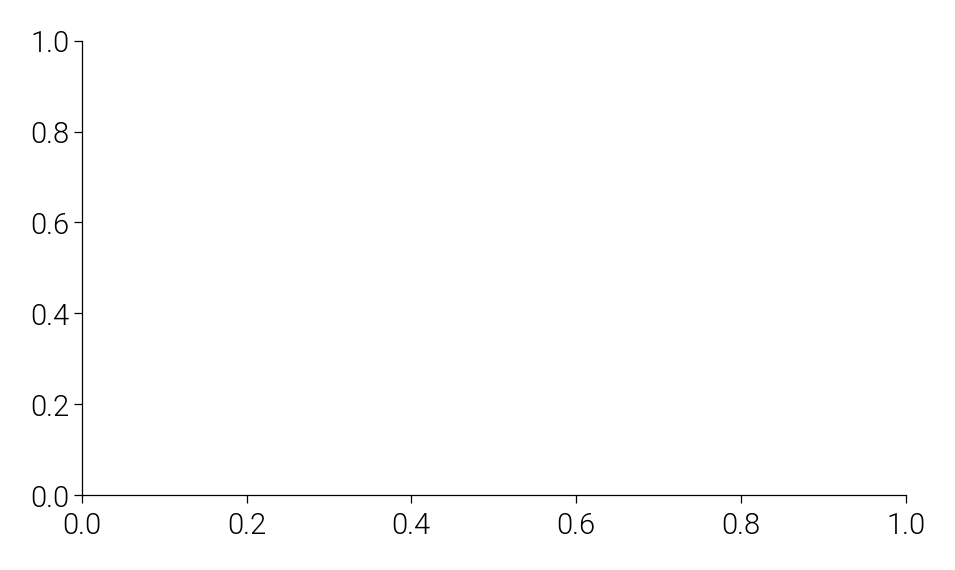

In [45]:
# ======= 플랏 스타일(서식)만 변경 (데이터/계산 동일) =======

# 축/범례/폰트 등은 notebook 상단 플롯 스타일(1-158) 체계 차용
X_LIM_CO2 = (0, 24)
Y_LIM_CO2 = (0, 8)
XTICKS = np.arange(0, 24 + 1, 6)
YTICKS_CO2 = np.arange(0, 6 + 0.1, 1)
YTICKS_PME = np.arange(0, 30 + 0.1, 5)

# ===== 라인 스타일 변수화 =====
GB_CO2_COLOR = 'oc.green4'
GB_CO2_LW    = dm.lw(0)
GB_CO2_STYLE = '-'

HPB_CO2_COLOR = 'oc.pink4'
HPB_CO2_LW    = dm.lw(0)
HPB_CO2_STYLE = '-'

GB_PME_COLOR = 'oc.green7'
GB_PME_LW    = dm.lw(0)
GB_PME_STYLE = ':'

HPB_PME_COLOR = 'oc.pink7'
HPB_PME_LW    = dm.lw(0)
HPB_PME_STYLE = ':'

fig, ax_co2 = plt.subplots(1, 1, figsize=(dm.cm2in(9), dm.cm2in(5)))

# 데이터 준비
gb_co2 = country_results['South Korea']['gb_results']['E_NG [W]'] * enex.W2kW * KOREA_TECH_PARAMS['gas'].co2_emission_factor
hpb_co2 = country_results['South Korea']['hpb_results']['E_tot [W]'] * enex.W2kW * elec_co2_factor['South Korea']

# GB plot
ax_co2.plot(
    time_h[:-1], gb_co2,
    color=GB_CO2_COLOR,
    linestyle=GB_CO2_STYLE,
    linewidth=GB_CO2_LW,
    label='Gas boiler'
)

# HPB (나라별) plot
for idx, (country, result) in enumerate(country_results.items()):
    ax_co2.plot(
        time_h[:-1], hpb_co2,
        color=HPB_CO2_COLOR,
        linewidth=HPB_CO2_LW,
        linestyle=HPB_CO2_STYLE,
        label=f'Heat pump boiler'
    )

ax_co2.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
ax_co2.set_ylabel('CO$_2$ emission [kg CO$_2$/h]', fontsize=fs['label'], labelpad=pad['label'])
ax_co2.set_xlim(X_LIM_CO2)
ax_co2.set_xticks(XTICKS)
ax_co2.set_yticks(YTICKS_CO2)
ax_co2.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_co2.grid(True, alpha=0.3)

# 범례 스타일 notebook style로 통일
handles, labels = ax_co2.get_legend_handles_labels()
ax_co2.legend(handles, labels, loc='upper left', fontsize=fs['legend'],
              bbox_to_anchor=(0.0, 1.0), ncols=1,
              handlelength=1.5, columnspacing=2, labelspacing=0.5)

# Twin y-axis for Primary Energy
ax_pme = ax_co2.twinx()
ax_pme.spines['right'].set_visible(True)

gb_pme = country_results['South Korea']['gb_results']['E_NG [W]'] * enex.W2kW * KOREA_TECH_PARAMS['gas'].primary_energy_factor
hpb_pme = country_results['South Korea']['hpb_results']['E_tot [W]'] * enex.W2kW * elec_primary_energy_factor['South Korea']

# GB plot - Primary energy
ax_pme.plot(
    time_h[:-1], gb_pme,
    color=GB_PME_COLOR,
    linestyle=GB_PME_STYLE,
    linewidth=GB_PME_LW,
    label='Gas boiler'
)
# HPB plot - Primary energy
for idx, (country, result) in enumerate(country_results.items()):
    ax_pme.plot(
        time_h[:-1], hpb_pme,
        color=HPB_PME_COLOR,
        linewidth=HPB_PME_LW,
        linestyle=HPB_PME_STYLE,
        label=f'Heat pump boiler'
    )

ax_pme.set_ylabel('Primary energy use [kW]', fontsize=fs['label'], labelpad=pad['label'])
ax_pme.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_pme.set_ylim(YTICKS_PME[0], YTICKS_PME[-1])
ax_pme.set_yticks(YTICKS_PME)  # PME 데이터는 YTICKS_PME로 적용
ax_pme.grid(False)
ax_pme.set_xlim(X_LIM_CO2)
ax_pme.set_xticks(XTICKS)

# 범례는 우측 상단 (Primary energy용)
handles, labels = ax_pme.get_legend_handles_labels()
legend_pme = ax_pme.legend(handles = handles,
              labels = labels,
              fontsize=fs['legend'],
              loc='upper right', bbox_to_anchor=(0.99, 1.0),
              ncols=1, handlelength=1.5, columnspacing=2, labelspacing=0.5)
ax_pme.add_artist(legend_pme)

# 전체 simple_layout/저장 notebook 상단 style 적용
dm.simple_layout(fig, margins=[0.05, 0.05, 0.05, 0.05], bbox=[0, 1, 0, 1])
plt.savefig('../figure/co2_emission_timeseries.png', dpi=300, bbox_inches='tight')
plt.savefig('../figure/co2_emission_timeseries.svg', dpi=300, bbox_inches='tight', transparent=True)
dm.save_and_show(fig, size=600)

## 4.2.3 CO2 & Primary energy use variation according to grid mix

In [51]:
# ======= 재생에너지 비율별 CO2 및 Primary Energy 비교 플롯 =======

# 플롯별 min/max/margin 변수(최상단 정의) + int형 인자, margin 인자 각각 추가
AX_CO2_YMIN = 0      # float/None, y축(좌) 최소값
AX_CO2_YMAX = 50     # float/None, y축(좌) 최대값
AX_CO2_YINT = 10
AX_CO2_YMAR = 0.05   # float/None, y축(좌) margin

AX_PME_YMIN = 0      # float/None, y축(우) 최소값
AX_PME_YMAX = 1000    # float/None, y축(우) 최대값
AX_PME_YINT = 200
AX_PME_YMAR = 0.05   # float/None, y축(우) margin

AX_XMIN = 11         # float/int/None, x축 최소값
AX_XMAX = 100       # float/int/None, x축 최대값
AX_XMAR = 0.05      # float/None, x축 margin

# 5. 플롯 생성
# ===== 플롯 스타일 변수 =====
GB_CO2_COLOR = 'oc.green4'
GB_CO2_LW = dm.lw(0)
GB_CO2_MARKER = '^'    # 세모 마커
GB_CO2_MARKERSIZE = 2

HPB_CO2_COLOR = 'oc.pink4'
HPB_CO2_LW = dm.lw(0)
HPB_CO2_MARKER = '^'   # 세모 마커
HPB_CO2_MARKERSIZE = 2

GB_PME_COLOR = 'oc.green7'
GB_PME_LW = dm.lw(0)
GB_PME_MARKER = 'o'
GB_PME_MARKERSIZE = 2

HPB_PME_COLOR = 'oc.pink7'
HPB_PME_LW = dm.lw(0)
HPB_PME_MARKER = 'o'
HPB_PME_MARKERSIZE = 2

# sweep_renewable_fraction 함수 import 확인 및 추가
from grid_mix_analysis import sweep_renewable_fraction

# 1. 한국의 현재 grid mix를 base_mix로 설정
korea_mix_data = COUNTRY_GRID_MIX['South Korea']
base_mix = PowerGenerationMix(
    coal=korea_mix_data['coal'],
    gas=korea_mix_data['gas'],
    nuclear=korea_mix_data['nuclear'],
    renewable=korea_mix_data['renewable'],
    oil=korea_mix_data['oil'],
    other=korea_mix_data['other']
)

# 재생에너지 세부 비율 가져오기
renewable_weights = get_country_renewable_tech_mix('South Korea')

# 재생에너지 비율 리스트: 11% (현재)부터 100%까지
renewable_fractions = [0.11, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.0]

# 2. 각 재생에너지 비율에 대한 PEF와 CO2 factor 계산
sweep_results = sweep_renewable_fraction(
    renewable_fractions=renewable_fractions,
    base_mix=base_mix,
    tech_params=KOREA_TECH_PARAMS,
    renewable_weights=renewable_weights
)

# 3. 기존 시뮬레이션 결과에서 전력 사용량 가져오기
gb_energy_W = country_results['South Korea']['gb_results']['E_NG [W]'].values  # 천연가스 사용량 [W]
hpb_energy_W = country_results['South Korea']['hpb_results']['E_tot [W]'].values  # 총 전력 사용량 [W]

# GB는 천연가스 직접 연소이므로 재생에너지 비율과 무관하게 동일한 factor 사용
co2_factor_gas = KOREA_TECH_PARAMS['gas'].co2_emission_factor  # [kg CO2/kWh]
pef_gas = KOREA_TECH_PARAMS['gas'].primary_energy_factor  # [--]

# 4. 각 재생에너지 비율에 대해 총 CO2 및 Primary Energy 계산 (적분)
gb_co2_total = []  # 총 CO2 배출량 [kg CO2]
gb_pme_total = []  # 총 Primary Energy [MJ]
hpb_co2_total = []  # 총 CO2 배출량 [kg CO2]
hpb_pme_total = []  # 총 Primary Energy [MJ]

for idx, row in sweep_results.iterrows():
    ren_frac = row['renewable_fraction']
    co2_factor_grid = row['co2_factor']  # [kg CO2/kWh]
    pef_grid = row['pef']  # [--]
    
    # GB 계산 (재생에너지 비율과 무관)
    gb_co2_hourly = gb_energy_W * enex.W2kW * co2_factor_gas  # [kg CO2/h]
    gb_co2 = np.sum(gb_co2_hourly * dt_s / 3600)  # 적분: [kg CO2]
    
    gb_pme_hourly_kWh = gb_energy_W * enex.W2kW * pef_gas  # [kW·h/h]
    gb_pme_kWh = np.sum(gb_pme_hourly_kWh * dt_s / 3600)  # 적분: [kW·h]
    gb_pme_MJ = gb_pme_kWh * 3.6  # [MJ]

    # HPB 계산 (재생에너지 비율에 따라 factor 변화)
    hpb_co2_hourly = hpb_energy_W * enex.W2kW * co2_factor_grid  # [kg CO2/h]
    hpb_co2 = np.sum(hpb_co2_hourly * dt_s / 3600)  # 적분: [kg CO2]
    
    hpb_pme_hourly_kWh = hpb_energy_W * enex.W2kW * pef_grid  # [kW·h/h]
    hpb_pme_kWh = np.sum(hpb_pme_hourly_kWh * dt_s / 3600)  # 적분: [kW·h]
    hpb_pme_MJ = hpb_pme_kWh * 3.6  # [MJ]

    gb_co2_total.append(gb_co2)
    gb_pme_total.append(gb_pme_MJ)
    hpb_co2_total.append(hpb_co2)
    hpb_pme_total.append(hpb_pme_MJ)

# x축: 재생에너지 비율 [%]
x_renewable_pct = [f * 100 for f in renewable_fractions]

fig, ax_co2 = plt.subplots(1, 1, figsize=(dm.cm2in(9), dm.cm2in(5)))

# 먼저 grid를 그려서 가장 뒤에 오게 한다.
ax_co2.grid(True, alpha=0.3, zorder=0)

# 좌측 y축: CO2 emission [kg CO2]
ax_co2.plot(
    x_renewable_pct, gb_co2_total,
    color=GB_CO2_COLOR,
    linewidth=GB_CO2_LW,
    marker=GB_CO2_MARKER,      # 세모로 적용
    markersize=GB_CO2_MARKERSIZE,
    label='GB (CO$_2$)',
    zorder=2
)

ax_co2.plot(
    x_renewable_pct, hpb_co2_total,
    color=HPB_CO2_COLOR,
    linewidth=HPB_CO2_LW,
    marker=HPB_CO2_MARKER,
    markersize=HPB_CO2_MARKERSIZE,
    label='HPB (CO$_2$)',
    zorder=2
)

ax_co2.set_xlabel('Renewable energy fraction [%]', fontsize=fs['label'], labelpad=pad['label'])
ax_co2.set_ylabel('CO$_2$ emission [kg CO$_2$/day]', fontsize=fs['label'], labelpad=pad['label'])
ax_co2.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
ax_co2.set_xticks(x_renewable_pct)

# float 범위 min/max 적용 (None이면 자동)
ax_co2.set_xlim(AX_XMIN, AX_XMAX)
ax_co2.set_ylim(AX_CO2_YMIN, AX_CO2_YMAX)
# int min/max 있을 경우 적용(우선순위 뒤)
ax_co2.set_xlim(AX_XMIN, AX_XMAX)
ax_co2.set_ylim(AX_CO2_YMIN, AX_CO2_YMAX)

# YINT 인자 활용해서 tick 간격 지정
if AX_CO2_YINT is not None:
    ax_co2.set_yticks(np.arange(AX_CO2_YMIN, AX_CO2_YMAX + AX_CO2_YINT, AX_CO2_YINT))

# tick margin 적용 (matplotlib은 margin 인자를 set_xlim/set_ylim에서 사용할 수도 있고, 수동 ticks로 조절 가능)
if AX_CO2_YMAR is not None:
    ylims = ax_co2.get_ylim()
    range_y = ylims[1] - ylims[0]
    ax_co2.set_ylim(ylims[0] - AX_CO2_YMAR*range_y, ylims[1])
if AX_XMAR is not None:
    xlims = ax_co2.get_xlim()
    range_x = xlims[1] - xlims[0]
    ax_co2.set_xlim(xlims[0] - AX_XMAR*range_x, xlims[1] + AX_XMAR*range_x)

# 범례 (좌측)
handles_co2, labels_co2 = ax_co2.get_legend_handles_labels()
ax_co2.legend(handles_co2, labels_co2, loc='upper left', fontsize=fs['legend'],
              bbox_to_anchor=(0.0, 1.0), ncols=1,
              handlelength=1.5, columnspacing=2, labelspacing=0.5)

# 우측 y축: Primary Energy [MJ]
ax_pme = ax_co2.twinx()
ax_pme.spines['right'].set_visible(True)

# ax_pme는 grid를 그리지 않음으로써 뒤쪽에 안 겹치게(그래도 grid 필요시, zorder 조절)
ax_pme.plot(
    x_renewable_pct, gb_pme_total,
    color=GB_PME_COLOR,
    linewidth=GB_PME_LW,
    marker=GB_PME_MARKER,
    markersize=GB_PME_MARKERSIZE,
    label='GB (Primary)',
    zorder=2
)

ax_pme.plot(
    x_renewable_pct, hpb_pme_total,
    color=HPB_PME_COLOR,
    linewidth=HPB_PME_LW,
    marker=HPB_PME_MARKER,
    markersize=HPB_PME_MARKERSIZE,
    label='HP (Primary)',
    zorder=2
)

ax_pme.set_ylabel('Primary energy use [MJ/day]', fontsize=fs['label'], labelpad=pad['label'])
ax_pme.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
ax_pme.grid(False)
ax_pme.set_xticks(x_renewable_pct)

# float min/max 적용 (None이면 자동)
ax_pme.set_xlim(AX_XMIN, AX_XMAX)
ax_pme.set_ylim(AX_PME_YMIN, AX_PME_YMAX)
# int min/max 있을 경우 적용(우선순위 뒤)
ax_pme.set_xlim(AX_XMIN, AX_XMAX)
ax_pme.set_ylim(AX_PME_YMIN, AX_PME_YMAX)

# YINT 인자 활용해서 tick 간격 지정
if AX_PME_YINT is not None:
    ax_pme.set_yticks(np.arange(AX_PME_YMIN, AX_PME_YMAX + AX_PME_YINT, AX_PME_YINT))

# tick margin 적용 (우축)
ylims = ax_pme.get_ylim()
range_y = ylims[1] - ylims[0]
ax_pme.set_ylim(ylims[0] - AX_PME_YMAR*range_y, ylims[1])
xlims = ax_pme.get_xlim()
range_x = xlims[1] - xlims[0]
ax_pme.set_xlim(xlims[0] - AX_XMAR*range_x, xlims[1] + AX_XMAR*range_x)

# 범례 (우측)
handles_pme, labels_pme = ax_pme.get_legend_handles_labels()
legend_pme = ax_pme.legend(handles_pme, labels_pme,
              fontsize=fs['legend'],
              loc='upper right', bbox_to_anchor=(0.99, 1.0),
              ncols=1, handlelength=1.5, columnspacing=2, labelspacing=0.5)
ax_pme.add_artist(legend_pme)

# 전체 simple_layout/저장 - margin 인자 사용
dm.simple_layout(fig, bbox=[0, 1, 0.02, 1])
plt.savefig('../figure/renewable_sweep_co2_pme.png', dpi=300, bbox_inches='tight')
plt.savefig('../figure/renewable_sweep_co2_pme.svg', dpi=300, bbox_inches='tight', transparent=True)
dm.save_and_show(fig, size=600)

## 4.2 Primary energy use

### 4.2.1 Primary energy use

In [ ]:
fig = plt.figure(figsize=(dm.cm2in(17), dm.cm2in(5)), dpi=200)
gs = fig.add_gridspec(
    nrows=1, ncols=1,
    left=0.12, right=0.95,
    top=0.95, bottom=0.15,
    hspace=0.3
)
ax = fig.add_subplot(gs[0, 0])

colors = ['oc.blue', 'oc.green', 'oc.red', 'oc.purple', 'oc.orange']
# GB 플롯 (첫 번째 국가의 데이터 사용)
# 누적 CO2 배출량 계산: E [W] * dt_s [s] * W2kW * s2h * co2_factor [kg CO2/kWh] = CO2 [kg CO2], 누적합 적용
ax.plot(
    time_h,
    country_results['South Korea']['gb_results']['E_NG [W]'] * enex.W2kW * DEFAULT_TECH_PARAMS['gas'].primary_energy_factor, # Cumulative CO2 [kg CO2] (natural gas direct combustion)
    color='oc.gray7',
    linestyle='--',
    linewidth=dm.lw(0.5),
    label='GB'
)

# HPB 플롯 (나라별)
for idx, (country, result) in enumerate(country_results.items()):
    ax.plot(
        time_h,
        country_results[country]['hpb_results']['E_tot [W]']* enex.W2kW * elec_primary_energy_factor[country], # Cumulative CO2 [kg CO2]
        color=colors[idx % len(colors)] + '4',
        linewidth=dm.lw(0.5),
        label=f'HPB ({country})'
    )

ax.set_xlabel('Time [Hour]', fontsize=dm.fs(0))
ax.set_ylabel('CO$_2$ Emission [kg CO$_2$/h]', fontsize=dm.fs(0))
ax.legend(fontsize=dm.fs(-1), loc='best', ncol=3)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0, 24)
ax.set_ylim(0, 30)

# 틱 설정
ax.set_xticks([0, 6, 12, 18, 24])
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

dm.simple_layout(fig)
# plt.savefig('../figure/co2_emission_timeseries.png', dpi=300, bbox_inches='tight')
# plt.savefig('../figure/co2_emission_timeseries.svg', dpi=300, bbox_inches='tight')
dm.save_and_show(fig, size=600)

기상과 전력믹스를 같이 해버리면 비교가 흐려짐. 기상 고정 전력믹스 흔들기, 전력믹스 고정 기상 흔들기 구분을 하는게 (레젠드에) 발표할 때 넣을 것과 논문에 넣을 것을 고민하면서 그리기.
일별로 분석할지 시간 스케일로 분석할지도 고민
현황에 대한 비교로서 할 수 있는 것은 현재와 같이 각국의 전력 믹스가 다른 상황에서 - 
우리가 만든 시나리오(ex 한국의 재생에너지 비율이 이렇게 늘어나면 이렇게 될 거다) -> 전력 믹스에 대한 모델. 

### 4.2.2 Primary energy use (Cumulative)

In [ ]:
fig = plt.figure(figsize=(dm.cm2in(17), dm.cm2in(5)), dpi=200)
gs = fig.add_gridspec(
    nrows=1, ncols=1,
    left=0.12, right=0.95,
    top=0.95, bottom=0.15,
    hspace=0.3
)
ax = fig.add_subplot(gs[0, 0])

colors = ['oc.blue', 'oc.green', 'oc.red', 'oc.purple', 'oc.orange']
# GB 플롯 (첫 번째 국가의 데이터 사용)
# 누적 CO2 배출량 계산: E [W] * dt_s [s] * W2kW * s2h * co2_factor [kg CO2/kWh] = CO2 [kg CO2], 누적합 적용
ax.plot(
    time_h,
    np.cumsum(country_results['South Korea']['gb_results']['E_NG [W]'] * enex.W2GW * dt_s * DEFAULT_TECH_PARAMS['gas'].primary_energy_factor), # [GJ]
    color='oc.gray7',
    linestyle='--',
    linewidth=dm.lw(0.5),
    label='GB'
)

# HPB 플롯 (나라별)
for idx, (country, result) in enumerate(country_results.items()):
    ax.plot(
        time_h,
        np.cumsum(country_results[country]['hpb_results']['E_tot [W]']* enex.W2GW * dt_s * elec_primary_energy_factor[country]), # [GJ]
        color=colors[idx % len(colors)] + '4',
        linewidth=dm.lw(0.5),
        label=f'HPB ({country})'
    )

ax.set_xlabel('Time [Hour]', fontsize=dm.fs(0))
ax.set_ylabel('Primary Energy Use [GJ]', fontsize=dm.fs(0))
ax.legend(fontsize=dm.fs(-1), loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0, 24)

# 틱 설정
ax.set_xticks([0, 6, 12, 18, 24])
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

dm.simple_layout(fig)
# plt.savefig('../figure/co2_emission_timeseries.png', dpi=300, bbox_inches='tight')
# plt.savefig('../figure/co2_emission_timeseries.svg', dpi=300, bbox_inches='tight')
dm.save_and_show(fig, size=600)

### 5.1.3 exergy efficiency

In [232]:
# 온도 타임시리즈 플롯
fig = plt.figure(figsize=(dm.cm2in(17), dm.cm2in(5)), dpi=200)
gs = fig.add_gridspec(
    nrows=1, ncols=1,
    left=0.12, right=0.95,
    top=0.95, bottom=0.15,
    hspace=0.3
)
ax = fig.add_subplot(gs[0, 0])

# GB 플롯 (연소기 출구 온도)
if len(country_results) > 0:
    first_country = list(country_results.keys())[0]
    time_hours = country_results[first_country]['time_hours']
    # GB 온도 데이터 (연소기 출구 온도 또는 서비스 온도)
    if 'T_w_comb_out [°C]' in gb_results.columns:
        gb_temp = gb_results['T_w_comb_out [°C]'].values
    elif 'T_serv_w [°C]' in gb_results.columns:
        gb_temp = gb_results['T_serv_w [°C]'].values
    else:
        gb_temp = None
    
    if gb_temp is not None:
        mask = gb_temp > 0
        if mask.any():
            ax.plot(time_hours[mask], gb_temp[mask], color='oc.gray7', linestyle='--', linewidth=dm.lw(0.5), label='GB (Combustion Outlet)')

# HPB 플롯 (저탕조 온도, 나라별)
for idx, (country, result) in enumerate(country_results.items()):
    time_hours = result['time_hours']
    # HPB 저탕조 온도 데이터
    if 'T_tank_w [°C]' in hpb_results.columns:
        hpb_temp = hpb_results['T_tank_w [°C]'].values
        mask = hpb_temp > 0
        if mask.any():
            ax.plot(
                time_hours[mask],
                hpb_temp[mask],
                color=colors[idx % len(colors)],
                linewidth=dm.lw(0.5),
                label=f'HPB Tank ({country})'
            )

ax.set_xlabel('Time [Hour]', fontsize=dm.fs(0))
ax.set_ylabel('Temperature [°C]', fontsize=dm.fs(0))
ax.set_title('Temperature Time Series', fontsize=dm.fs(1), fontweight=dm.fw(1))
ax.legend(fontsize=dm.fs(-1), loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0, 24)

# 틱 설정
ax.set_xticks([0, 6, 12, 18, 24])
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

dm.simple_layout(fig)
dm.save_and_show(fig, size=600)


KeyError: 'time_hours'

In [233]:
# 엑서지 효율 타임시리즈 플롯
fig = plt.figure(figsize=(dm.cm2in(17), dm.cm2in(5)), dpi=200)
gs = fig.add_gridspec(
    nrows=1, ncols=1,
    left=0.12, right=0.95,
    top=0.95, bottom=0.15,
    hspace=0.3
)
ax = fig.add_subplot(gs[0, 0])

# GB 플롯
if len(country_results) > 0:
    first_country = list(country_results.keys())[0]
    time_hours = country_results[first_country]['time_hours']
    gb_exergy = country_results[first_country]['gb_exergy_eff']
    # 0이 아닌 값만 플롯
    mask = gb_exergy > 0
    if mask.any():
        ax.plot(time_hours[mask], gb_exergy[mask], color='oc.gray7', linestyle='--', linewidth=dm.lw(0.5), label='GB')

# HPB 플롯 (나라별)  
for idx, (country, result) in enumerate(country_results.items()):
    hpb_exergy = result['hpb_exergy_eff']
    mask = hpb_exergy > 0
    if mask.any():
        ax.plot(
            result['time_hours'][mask],
            hpb_exergy[mask],
            color=colors[idx % len(colors)],
            linewidth=dm.lw(0.5),
            label=f'HPB ({country})'
        )

ax.set_xlabel('Time [Hour]', fontsize=dm.fs(0))
ax.set_ylabel('Exergy Efficiency [-]', fontsize=dm.fs(0))
ax.set_title('Exergy Efficiency Time Series', fontsize=dm.fs(1), fontweight=dm.fw(1))
ax.legend(fontsize=dm.fs(-1), loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0, 24)

# 틱 설정
ax.set_xticks([0, 6, 12, 18, 24])
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

dm.simple_layout(fig)
dm.save_and_show(fig, size=600)


KeyError: 'time_hours'

### System COP

In [ ]:
# 에너지 효율(COP) 타임시리즈 플롯 (HPB만)
fig = plt.figure(figsize=(dm.cm2in(17), dm.cm2in(5)), dpi=200)
gs = fig.add_gridspec(
    nrows=1, ncols=1,
    left=0.12, right=0.95,
    top=0.95, bottom=0.15,
    hspace=0.3
)
ax = fig.add_subplot(gs[0, 0])

# GB 플롯 (고정값)
if len(country_results) > 0:
    first_country = list(country_results.keys())[0]
    time_hours = country_results[first_country]['time_hours']
    gb_energy_eff = country_results[first_country]['gb_energy_eff']
    ax.axhline(y=gb_energy_eff[0], color='oc.gray7', linestyle='--', linewidth=dm.lw(0.5), label=f'GB ($\eta$={gb_energy_eff[0]:.2f})')

# HPB 플롯 (나라별)
for idx, (country, result) in enumerate(country_results.items()):
    hpb_energy_eff = result['hpb_energy_eff']
    mask = hpb_energy_eff > 0
    if mask.any():
        ax.plot(
            result['time_hours'][mask],
            hpb_energy_eff[mask],
            color=colors[idx % len(colors)],
            linewidth=dm.lw(0.5),
            label=f'HPB ({country})'
        )

ax.set_xlabel('Time [Hour]', fontsize=dm.fs(0))
ax.set_ylabel('Energy Efficiency (COP) [-]', fontsize=dm.fs(0))
ax.set_title('Energy Efficiency (COP) Time Series', fontsize=dm.fs(1), fontweight=dm.fw(1))
ax.legend(fontsize=dm.fs(-1), loc='best', ncol=2)
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(0, 24)

# 틱 설정
ax.set_xticks([0, 6, 12, 18, 24])
ax.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

dm.simple_layout(fig)
dm.save_and_show(fig, size=600)


## 5.2 일일 적분값 비교

나라별 일일 총 CO2 배출량과 Primary Energy 사용량을 비교합니다.


In [ ]:
# 일일 총 CO2 배출량 비교 바 차트
fig = plt.figure(figsize=(dm.cm2in(17), dm.cm2in(6)), dpi=200)
gs = fig.add_gridspec(
    nrows=1, ncols=2,
    left=0.10, right=0.95,
    top=0.95, bottom=0.15,
    hspace=0.3, wspace=0.3
)

# CO2 배출량
ax1 = fig.add_subplot(gs[0, 0])
countries = list(country_results.keys())
x_pos = np.arange(len(countries))
width = 0.35

gb_co2_totals = [country_results[c]['gb_co2_total'] for c in countries]
hpb_co2_totals = [country_results[c]['hpb_co2_total'] for c in countries]

bars1 = ax1.bar(x_pos - width/2, gb_co2_totals, width, label='GB', color='oc.gray7')
bars2 = ax1.bar(x_pos + width/2, hpb_co2_totals, width, label='HPB', color=colors[:len(countries)])

ax1.set_xlabel('Country', fontsize=dm.fs(0))
ax1.set_ylabel('Daily CO$_2$ Emission [kg CO$_2$/day]', fontsize=dm.fs(0))
ax1.set_title('Daily CO$_2$ Emission Comparison', fontsize=dm.fs(1), fontweight=dm.fw(1))
ax1.set_xticks(x_pos)
ax1.set_xticklabels(countries, rotation=45, ha='right', fontsize=dm.fs(-1))
ax1.legend(fontsize=dm.fs(-1))
ax1.grid(True, alpha=0.3, linestyle=':', axis='y')

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=dm.fs(-2))

# Primary Energy 사용량
ax2 = fig.add_subplot(gs[0, 1])
gb_pe_totals = [country_results[c]['gb_primary_energy_total'] for c in countries]
hpb_pe_totals = [country_results[c]['hpb_primary_energy_total'] for c in countries]

bars3 = ax2.bar(x_pos - width/2, gb_pe_totals, width, label='GB', color='oc.gray7')
bars4 = ax2.bar(x_pos + width/2, hpb_pe_totals, width, label='HPB', color=colors[:len(countries)])

ax2.set_xlabel('Country', fontsize=dm.fs(0))
ax2.set_ylabel('Daily Primary Energy Use [kWh/day]', fontsize=dm.fs(0))
ax2.set_title('Daily Primary Energy Use Comparison', fontsize=dm.fs(1), fontweight=dm.fw(1))
ax2.set_xticks(x_pos)
ax2.set_xticklabels(countries, rotation=45, ha='right', fontsize=dm.fs(-1))
ax2.legend(fontsize=dm.fs(-1))
ax2.grid(True, alpha=0.3, linestyle=':', axis='y')

# 값 표시
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=dm.fs(-2))

dm.simple_layout(fig)
dm.save_and_show(fig, size=600)

## 5.3 요약 테이블

나라별 주요 지표를 요약한 테이블을 생성합니다.


In [ ]:
# 요약 테이블 생성
summary_data = []
for country, result in country_results.items():
    summary_data.append({
        'Country': country,
        'Renewable [%]': result['mix'].renewable * 100,
        'PEF [-]': result['pef_electricity'],
        'CO2 Factor [kg/kWh]': result['co2_factor_electricity'],
        'GB CO2 [kg/day]': result['gb_co2_total'],
        'HPB CO2 [kg/day]': result['hpb_co2_total'],
        'CO2 Reduction [%]': (1 - result['hpb_co2_total'] / result['gb_co2_total']) * 100 if result['gb_co2_total'] > 0 else 0,
        'GB PE [kWh/day]': result['gb_primary_energy_total'],
        'HPB PE [kWh/day]': result['hpb_primary_energy_total'],
        'PE Reduction [%]': (1 - result['hpb_primary_energy_total'] / result['gb_primary_energy_total']) * 100 if result['gb_primary_energy_total'] > 0 else 0,
        'GB Exergy Eff [-]': result['gb_exergy_eff_avg'],
        'HPB Exergy Eff [-]': result['hpb_exergy_eff_avg'],
        'GB Energy Eff [-]': result['gb_energy_eff_avg'],
        'HPB Energy Eff [-]': result['hpb_energy_eff_avg'],
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(3)

# 테이블 출력
print("=" * 120)
print("나라별 비교 요약")
print("=" * 120)
print(summary_df.to_string(index=False))
print("=" * 120)

# CSV로 저장
summary_df.to_csv('../result/country_comparison_summary.csv', index=False)
print("\n요약 테이블이 '../result/country_comparison_summary.csv'에 저장되었습니다.")


나라별 비교 요약
    Country  Renewable [%]  PEF [-]  CO2 Factor [kg/kWh]  GB CO2 [kg/day]  HPB CO2 [kg/day]  CO2 Reduction [%]  GB PE [kWh/day]  HPB PE [kWh/day]  PE Reduction [%]  GB Exergy Eff [-]  HPB Exergy Eff [-]  GB Energy Eff [-]  HPB Energy Eff [-]
South Korea           11.0    2.377                0.376           31.814             9.719             69.451           79.534            61.376            22.831              0.085               0.124                0.9               2.329
      China           37.0    2.085                0.513           31.814            13.248             58.356           79.534            53.846            32.298              0.085               0.124                0.9               2.329
    Germany           56.0    1.844                0.258           31.814             6.667             79.045           79.534            47.603            40.148              0.085               0.124                0.9               2.329
     Norway           

# 6. 결론 및 분석 요약

동적 시뮬레이션 결과를 바탕으로 나라별 전력 믹스에 따른 GB와 HPB의 성능을 비교 분석했습니다.

### 주요 발견사항:
1. **CO2 배출량**: 재생에너지 비율이 높은 나라일수록 HPB의 CO2 배출량이 감소합니다.
2. **Primary Energy**: 전력 믹스의 PEF에 따라 HPB의 Primary Energy 사용량이 달라집니다.
3. **효율**: HPB는 시간대별로 COP가 변동하며, 저탕조 열손실이 포함된 동적 거동을 보입니다.
4. **비교**: 재생에너지 비율이 높은 나라(예: Norway)에서는 HPB가 GB보다 환경적으로 유리합니다.


# 7. 그 외

## 7.1 히트펌프 보일러 증발, 응축 온도 테스트

In [26]:
# AirSourceHeatPumpBoiler 초기화
# 주의: 시뮬레이션은 이제 analyze_country_timeseries 함수 내에서 각 국가별로 실행됩니다.
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = 'R134a',
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 1000.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 3000.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 2,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_setpoint    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 20000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = dV_w_serv_m3s,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.01,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)


# 동적 시뮬레이션 실행 (주석 처리: 국가별로 다른 외기온도 사용)
T0_schedule = [10] * tN
hpb_results = hpb.analyze_dynamic(
    simulation_period_sec=simulation_period_sec,
    dt_s=dt_s,
    T_tank_w_init_C=60.0,  # 저탕조 초기 온도
    schedule_entries=schedule_entries,
    T0_schedule=T0_schedule,
    result_save_csv_path='../result/hpb_results.csv',
    # save_ph_diagram= True,
    # snapshot_save_path='../video'
)

print(f"AirSourceHeatPumpBoiler 시뮬레이션 완료: {len(hpb_results)} 타임스텝")
print(f"총 전력 사용량: {hpb_results['E_tot [W]'].sum() * dt_s * enex.W2kW * enex.s2h:.2f} kWh")

ASHPB Simulating: 100%|██████████| 1440/1440 [00:24<00:00, 58.02it/s] 


AirSourceHeatPumpBoiler 시뮬레이션 완료: 1440 타임스텝
총 전력 사용량: 3.18 kWh


In [28]:
# 증발기(inlet/outlet T1/T4)의 산술평균을 먼저 시간별로 계산한 뒤 전체 평균(=증발기 평균),
# 응축기(inlet/outlet T2/T3)의 산술평균을 먼저 시간별로 계산한 뒤 전체 평균(=응축기 평균)으로 비교
# 단, 평균 구간은 is_on 인자가 True인 구간에 한정함

# is_on이 True인 인덱스 필터
if 'is_on' in hpb_results:
    on_mask = hpb_results['is_on'] == True
else:
    on_mask = np.full(len(hpb_results), True)

# 평균 외기 온도: 전체 스케줄(외기 온도는 설비 여부와 무관)
T0_avg = np.mean(T0_schedule)

# 저탕조 온수 평균: is_on 구간에서만
T_tank_w_avg = np.mean(hpb_results.loc[on_mask, 'T_tank_w [°C]']) if 'T_tank_w [°C]' in hpb_results else np.nan

# 증발기 측(외기측): T1/T4 산술평균, is_on 구간에서만
if 'T1 [°C]' in hpb_results and 'T4 [°C]' in hpb_results:
    Tevap_arith = 0.5 * (hpb_results['T1 [°C]'] + hpb_results['T4 [°C]'])
    Tevap_mean = np.mean(Tevap_arith[on_mask])
else:
    Tevap_mean = np.nan

# 응축기 측(저탕조측): T2/T3 산술평균, is_on 구간에서만
if 'T2 [°C]' in hpb_results and 'T3 [°C]' in hpb_results:
    Tcond_arith = 0.5 * (hpb_results['T2 [°C]'] + hpb_results['T3 [°C]'])
    Tcond_mean = np.mean(Tcond_arith[on_mask])
else:
    Tcond_mean = np.nan

delta_Tevap_oa = Tevap_mean - T0_avg
delta_Tcond_tank = Tcond_mean - T_tank_w_avg if not np.isnan(T_tank_w_avg) else np.nan

print(f"평균 외기 온도: {T0_avg:.2f} °C")
print(f"증발기 측 온도 산술평균(운전 구간 평균): {Tevap_mean:.2f} °C")
print(f"증발기 산술평균이 외기보다 {abs(delta_Tevap_oa):.2f} °C {'낮음' if delta_Tevap_oa < 0 else '높음'}")

if not np.isnan(Tcond_mean) and not np.isnan(T_tank_w_avg):
    print(f"응축기 측 온도 산술평균(운전 구간 평균): {Tcond_mean:.2f} °C, 저탕조 온수 평균(운전 구간): {T_tank_w_avg:.2f} °C")
    print(f"응축기 산술평균이 저탕조 온수보다 {abs(delta_Tcond_tank):.2f} °C {'높음' if delta_Tcond_tank > 0 else '낮음'}")
else:
    print("응축기 산술평균 또는 저탕조 온수 평균 데이터가 부족합니다.")


평균 외기 온도: 14.50 °C
증발기 측 온도 산술평균(운전 구간 평균): 3.01 °C
증발기 산술평균이 외기보다 11.49 °C 낮음
응축기 측 온도 산술평균(운전 구간 평균): 80.59 °C, 저탕조 온수 평균(운전 구간): 59.03 °C
응축기 산술평균이 저탕조 온수보다 21.56 °C 높음


In [ ]:
# print(hpb_results[hpb_results['converged'] == False])
# hpb_error_row = hpb_results[hpb_results['converged'] == False].shape[0]
# if hpb_error_row > 0:
#     print(f"수렴 실패 행 수: {hpb_error_row}")
#     print("수렴 실패 행 정보:")
#     print(hpb_results[hpb_results['converged'] == False])
# else:
#     print('모든 결과 수렴')

Empty DataFrame
Columns: [is_on, converged, Q_cond_load [W], Q_ref_cond [W], Q_ref_evap [W], Q_LMTD_cond [W], Q_LMTD_evap [W], E_cmp [W], E_fan_ou [W], E_tot [W], cop [-], m_dot_ref [kg/s], cmp_rpm [rpm], dV_fan_ou [m3/s], dV_w_serv [m3/s], dV_w_sup_tank [m3/s], dV_w_sup_mix [m3/s], T0 [°C], T_air_ou_out [°C], T_air_ou_in [°C], T_tank_w [°C], T_serv_w [°C], T_sup_w [°C], T_cond [°C], T_evap [°C], T1 [°C], T2 [°C], T3 [°C], T4 [°C], P1 [Pa], P2 [Pa], P3 [Pa], P4 [Pa], h1 [J/kg], h2 [J/kg], h3 [J/kg], h4 [J/kg], s1 [J/(kg·K)], s2 [J/(kg·K)], s3 [J/(kg·K)], s4 [J/(kg·K)], x1 [J/kg], x2 [J/kg], x3 [J/kg], x4 [J/kg], X1 [W], X2 [W], X3 [W], X4 [W], X_cmp [W], X_fan_ou [W], X_a_ou_in [W], X_a_ou_out [W], X_ref_cond [W], X_tank_sup_w [W], X_tank_w [W], X_mix_sup_w [W], X_mix_serv_w [W], Xc_evap [W], Xc_cmp [W], Xc_ref_cond [W], Xc_exp [W], Xc_tank [W], Xc_mix [W], Xc_tot [W], X_flow_X1_to_X2 [W], X_flow_X2_to_X3 [W], X_flow_X3_to_X4 [W], X_flow_X4_to_X1 [W], X_tot [W], X_eff [-]]
Index: []

[

## 7.2 냉매 video용 그래프

In [36]:
# AirSourceHeatPumpBoiler 초기화
# 주의: 시뮬레이션은 이제 analyze_country_timeseries 함수 내에서 각 국가별로 실행됩니다.
ref = 'R410a'
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = ref,
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 500.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 1500.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 2,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_setpoint    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 10000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = 0.000333,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.01,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)


# 동적 시뮬레이션 실행 (주석 처리: 국가별로 다른 외기온도 사용)
simulation_period_sec = 120
hpb_results = hpb.analyze_dynamic(
    simulation_period_sec = simulation_period_sec,
    dt_s                  = simulation_period_sec,
    T_tank_w_init_C       = 50.0,
    schedule_entries      = [('0:00', '00:02', 1.0)], # 한타임스텝만 돌아가도록 설정
    T0_schedule           = [10],
    # result_save_csv_path  = '../result/hpb_results.csv',
    save_ph_diagram= True,
    snapshot_save_path=f'../video/{ref}_test'
)

ASHPB Simulating: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


## 7.3 냉매 종류 state plot

In [ ]:
# 6개 냉매에 대한 정상상태 분석 및 T-h 선도 비교

# 냉매 리스트

# 합리적인 냉매 종류 6가지
# R32: 현재 가정용 시장의 절대 강자. 기존 R410A를 빠르게 대체하고 있으며, 적절한 효율과 가격 경쟁력을 가집니다.
# R290 (프로판): 유럽 시장의 핵심. 낮은 GWP와 높은 출수 온도($70^\circ\text{C}$ 이상) 덕분에 실외기 일체형(Monobloc) 보일러에서 가장 선호됩니다.
# R744 (CO2): 급탕/고온수 전용. 영하의 날씨에서도 고온($90^\circ\text{C}$)을 뽑아내는 능력이 탁월하여 상업용 및 고급 가정용 급탕기에 주로 쓰입니다.
# R134a: 기존 고온용 표준. 스크류/터보 냉동기 및 중대형 히트펌프에 널리 퍼져 있어 여전히 유지보수 및 비교 데이터의 기준이 됩니다.
# R1234ze(E): 산업용 고온의 미래. R134a를 대체하며 대형 산업용 보일러나 지역 난방용 대형 히트펌프에 도입이 확대되고 있습니다.
# R410A: 레거시(Legacy) 대장. 신규 설치는 줄고 있지만, 기존 설치된 기기가 워낙 많아 성능 비교 시 반드시 포함해야 하는 기준점입니다.

refrigerants = [
    # --- 1. 자연 냉매 (Natural Refrigerants): 친환경, 고효율, 미래 표준 ---
    # "R744",      # 이산화탄소 (CO2): GWP 1. 고온수(90도) 생산에 최적. 급탕용(EcoCute) 표준. # 응축 없이 초임계 상태에서 작동하기 때문에 AirSourceHeatPumpBoiler 모델로 구현 불가능함
    "R290",      # 프로판 (Propane): GWP 3. 우수한 열역학 성능. 유럽 가정용 히트펌프의 대세. (가연성 주의)
    # "R717",      # 암모니아 (Ammonia): GWP 0. 산업용 대용량 시스템 최고 효율. (독성 주의)
    "R600a",     # 이소부탄 (Isobutane): GWP 3. 저압 냉매. 소형 시스템이나 냉장고, 고온용 혼합 냉매로 사용.

    # --- 2. HFO 계열 (Hydrofluoroolefins): 차세대 저 GWP 합성 냉매 ---
    "R1234ze(E)",# GWP < 1. 중대형 고온 히트펌프용. R134a 대체재로 주목받음.
    # "R1234yf",   # GWP < 1. 자동차 및 소형 히트펌프용. R134a 대체재.
    # "R1233zd(E)",# GWP 1. 저압 냉매. 터보 압축기 등 대형 산업용 히트펌프/폐열 회수에 적합.

    # --- 3. HFC 계열 (Transitional): 현재 주류이나 규제로 인해 대체 중 ---
    "R32",       # GWP 675. R410A 대체재. 현재 가정용 에어컨/히트펌프의 가장 대중적인 선택.
    "R134a",     # GWP 1430. 중온/고온용 표준이었으나 HFO로 대체 중. 데이터 비교용 기준(Baseline).
    "R410A",     # GWP 2088. 기존 가정용 표준. 임계온도가 낮아 고온 보일러엔 불리하지만, 비교군으로 필수.
]

# 분석 조건 설정
T_tank_w = 50.0  # 저탕조 온도 [°C]
T0 = 10.0        # 외기 온도 [°C]
dV_w_serv = 0.0001 # 급탕 유량 [m³/s] (정상상태이므로 0)

# 각 냉매에 대해 HPB 인스턴스 생성 및 분석 수행
hpb_instances = {}
results = {}

for ref in refrigerants:
    print(f"\n{ref} 분석 중...")
    try:
        # HPB 인스턴스 생성 (Cell 12의 파라미터와 동일, 냉매만 변경)
        hpb_instances[ref] = AirSourceHeatPumpBoiler(
            # 냉매/사이클/압축기 파라미터
            ref          = ref,
            V_disp_cmp   = 0.0005,
            eta_cmp_isen = 0.7,
            
            # 열교환기 파라미터 (상수 UA)
            UA_cond_design = 500.0,              # 응축기 열전달 계수 [W/K] (상수)
            UA_evap_design = 1500.0,             # 증발기 열전달 계수 [W/K] (상수)
            A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
            
            # 실외기 팬 파라미터 (정풍량)
            dV_ou_design      = 2,       # 실외기 설계 풍량 [m³/s] (정풍량)
            dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
            eta_fan_ou_design = 0.8,
            
            # 탱크/제어/부하 파라미터
            T_tank_w_setpoint    = 65.0,      # 저탕조 설정 온도 [°C]
            T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
            T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
            T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
            heater_capacity      = 10000.0,   # 히터 최대 용량 [W]
            dV_w_serv_m3s        = 0.000333,    # 최대 급탕 유량 [m³/s]
            
            # 탱크 물성
            r0      = 0.2,    # 탱크 반지름 [m]
            H       = 0.8,    # 탱크 높이 [m]
            x_shell = 0.01,   # 탱크 외벽 두께 [m]
            x_ins   = 0.05,   # 단열재 두께 [m]
            k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
            k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
            h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
        )
        
        # 정상상태 분석 수행
        result = hpb_instances[ref].analyze_steady(
            T_tank_w=T_tank_w,
            T0=T0,
            dV_w_serv=dV_w_serv,
            return_dict=True
        )
        
        results[ref] = result
        
    except Exception as e:
        print(f"  {ref} 분석 실패: {e}")
        results[ref] = None

print("\n분석 완료!")



R290 분석 중...
alp: 0.71
Q_cond_load [W]: 10498.051926748067

R600a 분석 중...
alp: 0.71
Q_cond_load [W]: 10498.051926748067

R1234ze(E) 분석 중...
alp: 0.71
Q_cond_load [W]: 10498.051926748067

R32 분석 중...
alp: 0.71
Q_cond_load [W]: 10498.051926748067

R134a 분석 중...
alp: 0.71
Q_cond_load [W]: 10498.051926748067

R410A 분석 중...
alp: 0.71
Q_cond_load [W]: 10498.051926748067

분석 완료!


In [59]:
# T-h 선도 2x3 그리드 플롯

import CoolProp.CoolProp as CP
from enex_analysis import calc_util as cu

# 축 범위 설정 (공통)
xmin, xmax = 0, 800  # 엔탈피 [kJ/kg]
ymin, ymax = -30, 150  # 온도 [°C]

# 선 두께 배열
LW = np.arange(0.5, 3.0, 0.25)

# 2x3 서브플롯 생성
nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(dm.cm2in(21), dm.cm2in(12)))
axes = axes.flatten()

# 색상 정의
color1 = 'oc.blue5'   # 포화 액체선
color2 = 'oc.red5'    # 포화 증기선
color3 = 'black'      # 사이클 경로 마커

# 각 냉매에 대해 T-h 선도 그리기
for idx, ref in enumerate(refrigerants):
    ax = axes[idx]
    result = results[ref]
    
    if result is None or not result.get('is_on', False):
        # OFF 상태이거나 결과가 없는 경우
        ax.text(0.5, 0.5, f'{ref}\n(OFF or Failed)', 
                ha='center', va='center', transform=ax.transAxes,
                fontsize=dm.fs(0))
        ax.set_title(ref, fontsize=dm.fs(0), pad=10)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=dm.fs(-1), labelpad=6)
        ax.set_ylabel('Temperature [°C]', fontsize=dm.fs(-1), labelpad=6)
        continue
    
    try:
        # 포화선 계산
        T_critical = cu.K2C(CP.PropsSI('Tcrit', ref))
        temps = np.linspace(cu.K2C(CP.PropsSI('Tmin', ref)) + 1, T_critical, 600)
        h_liq = [CP.PropsSI('H', 'T', cu.C2K(T), 'Q', 0, ref) / 1000 for T in temps]
        h_vap = [CP.PropsSI('H', 'T', cu.C2K(T), 'Q', 1, ref) / 1000 for T in temps]
        
        # 포화선 그리기
        ax.plot(h_liq, temps, color=color1, label='Saturated liquid', linewidth=LW[2])
        ax.plot(h_vap, temps, color=color2, label='Saturated vapor', linewidth=LW[2])
        
        # 사이클 상태점 추출
        h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * cu.J2kJ  # 엔탈피 [kJ/kg]
        T = np.array([result[f'T{i} [°C]'] for i in range(1, 5)])             # 온도 [°C]
        
        # 사이클 경로 구성 (닫힌 경로: 1→2→3→4→1)
        h_cycle = np.concatenate([h, h[:1]])
        T_cycle = np.concatenate([T, T[:1]])
        
        # 사이클 경로 그리기
        ax.plot(h_cycle, T_cycle, color='oc.gray5', label='Heat pump cycle',
                markerfacecolor=color3, markeredgecolor=color3,
                linewidth=LW[1], marker='o', linestyle=':', markersize=2)
        
        # 상태점 라벨 표시
        xdata = h
        ydata = T
        
        # 상태점 좌표 그룹핑 (소수점 3자리 반올림으로 동일 좌표 판단)
        groups = {}
        for i, (xi, yi) in enumerate(zip(xdata, ydata), start=1):
            key = (round(float(xi), 3), round(float(yi), 3))
            groups.setdefault(key, []).append(i)
        
        # 각 그룹에 대해 라벨 표시
        for (xg, yg), labels in groups.items():
            label_text = ",".join(map(str, labels))
            ax.annotate(label_text, (xg, yg),
                       xytext=(0, 3), textcoords='offset points',
                       ha='center', va='bottom',
                       fontsize=dm.fs(-1.5))
        
        # 축 설정
        ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=dm.fs(-1), labelpad=6)
        ax.set_ylabel('Temperature [°C]', fontsize=dm.fs(-1), labelpad=6)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.tick_params(axis='both', which='major', labelsize=dm.fs(-1.5), pad=4)
        
        # 범례 추가
        ax.legend(loc='upper left', bbox_to_anchor=(0.0, 0.99),
                 handlelength=1.5, labelspacing=0.5, columnspacing=2,
                 ncol=1, frameon=False, fontsize=dm.fs(-2))
        
        # 제목
        ax.set_title(ref, fontsize=dm.fs(0), pad=10, fontweight='bold')
        
    except Exception as e:
        # 오류 발생 시
        ax.text(0.5, 0.5, f'{ref}\nError: {str(e)[:30]}', 
                ha='center', va='center', transform=ax.transAxes,
                fontsize=dm.fs(-1))
        ax.set_title(ref, fontsize=dm.fs(0), pad=10)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

# 레이아웃 조정 (pad=0으로 간격을 거의 없앰, 필요시 pad 조정)
plt.subplots_adjust(wspace=0.5, hspace=0.6)
dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0, 1, 0, 1), verbose=False)

# 저장 및 표시
plt.savefig('../figure/refrigerant_comparison_T-h_diagram.svg', dpi=900, transparent=True)
plt.savefig('../figure/refrigerant_comparison_T-h_diagram.png', dpi=900, transparent=True)
dm.save_and_show(fig)


In [45]:
result = hpb_instances['R410A'].analyze_steady(
    T_tank_w=60,
    T0=-20,
    dV_w_serv=dV_w_serv,
    return_dict=True
    )
result

alp: 0.56
Q_cond_load [W]: 10531.103853496134


{'is_on': True,
 'converged': np.True_,
 'T_air_ou_in [°C]': -20.0,
 'T_air_ou_out [°C]': np.float64(-25.264956027066575),
 'T1 [°C]': np.float64(-30.010521267225442),
 'T2 [°C]': 132.7878794067189,
 'T3 [°C]': np.float64(62.597803339305585),
 'T4 [°C]': -30.04266440908225,
 'T_cond [°C]': 132.7878794067189,
 'T_tank_w [°C]': 60,
 'T_sup_w [°C]': 15.0,
 'T_serv_w [°C]': 40.0,
 'T0 [°C]': -20,
 'dV_fan_ou [m3/s]': 0.7329366313767424,
 'dV_w_serv [m3/s]': 0.0001,
 'dV_w_sup_tank [m3/s]': 5.555555555555556e-05,
 'dV_w_sup_mix [m3/s]': 4.4444444444444447e-05,
 'P1 [Pa]': 269232.29468592413,
 'P2 [Pa]': 4066376.566683286,
 'P3 [Pa]': 4066376.566683286,
 'P4 [Pa]': 269232.29468592413,
 'm_dot_ref [kg/s]': 0.05031134215951475,
 'cmp_rpm [rpm]': 572.5554108945884,
 'h1 [J/kg]': 409792.7175350635,
 'h2 [J/kg]': 524684.1322843527,
 'h3 [J/kg]': 315365.44982689177,
 'h4 [J/kg]': 315365.44982689177,
 's1 [J/(kg·K)]': 1875.0116903570888,
 's2 [J/(kg·K)]': 1962.942085460712,
 's3 [J/(kg·K)]': 1366.0

In [ ]:
hpb = AirSourceHeatPumpBoiler()

## 7.4 ASHPB 종합 분석 Video plot

### 데이터 취득

In [118]:
# Video frame generation for HPB simulation
# This cell generates video frames showing P-h/T-h diagrams, temperature timeseries, and power/COP plots

import matplotlib.gridspec as gridspec
import CoolProp.CoolProp as CP
from enex_analysis import calc_util as cu
import os

# Ensure video directory exists
os.makedirs('../video', exist_ok=True)

# ============================================================================
# 1. Simulation Setup
# ============================================================================

# 시뮬레이션 파라미터 설정
simulation_period_sec = 24 * enex.h2s  # 24시간
dt_s = 60  # 60 초
tN = int(simulation_period_sec / dt_s) # time step number
time_s = np.arange(tN + 1) * dt_s
time_h = time_s * enex.s2h

# 급탕 사용 스케줄 (동일한 패턴 사용)
schedule_entries = [
        # --- 아침 피크 ---
        # --- 0:00 - 6:00 (사용 0) ---
        ("6:00", "6:30", 0.5),
        ("6:30", "7:00", 0.9),
        ("7:00", "7:30", 1.0),  # <--- Peak (1.0)
        ("7:30", "8:00", 0.9),
        ("8:00", "8:30", 0.6),
        ("8:30", "9:00", 0.3),
        
        # --- 주간 (최소 0.05, 점심 피크) ---
        ("9:00", "11:30", 0.05), # 2.5시간 (5개 구간)
        ("11:30", "12:00", 0.2), # 점심 준비/손 씻기
        ("12:00", "12:30", 0.4), # 식사/설거지
        ("12:30", "13:00", 0.4), # 설거지/양치
        ("13:00", "13:30", 0.2), # 마무리
        ("13:30", "17:00", 0.05),# 3.5시간 (7개 구간)
        
        # --- 저녁 피크 ---
        ("17:00", "17:30", 0.3),
        ("17:30", "18:00", 0.5),
        ("18:00", "18:30", 0.8),
        ("18:30", "19:00", 0.9),
        ("19:00", "19:30", 0.8),
        ("19:30", "20:00", 0.7),
        
        # --- 저녁 (감소) ---
        ("20:00", "20:30", 0.5),
        ("20:30", "21:00", 0.4),
        ("21:00", "21:30", 0.3),
        ("21:30", "22:00", 0.2),
        # --- 22:00 - 24:00 (사용 0) ---
    ]

# 공통 온도 파라미터
T_serv_w = 40.0  # 서비스 급탕 온도 [°C]
T_sup_w = 15.0   # 급수(상수도) 온도 [°C]
T0 = 10.0         # 기준 온도 [°C]
T0_schedule = [T0] * tN

# HPB 인스턴스 생성
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = 'R134a',
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 500.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 1500.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 4,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_setpoint    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 10000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = 0.000333,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.01,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)

print(f"시뮬레이션 기간: {simulation_period_sec/3600:.0f}시간")
print(f"타임스텝: {dt_s}초")
print(f"총 타임스텝 수: {tN}")

# ============================================================================
# 2. Run Simulation and Save to CSV
# ============================================================================

results_df = hpb.analyze_dynamic(
    simulation_period_sec=simulation_period_sec,
    dt_s=dt_s,
    T_tank_w_init_C=60.0,
    schedule_entries=schedule_entries,
    T0_schedule=T0_schedule,
    result_save_csv_path='../video/hpb_results.csv',
    save_ph_diagram=False,
    snapshot_save_path=None,
    optimization_method='SLSQP',
)

print(f"시뮬레이션 완료. 결과 저장: ../video/hpb_results.csv")
print(f"총 {len(results_df)} 타임스텝 데이터")

시뮬레이션 기간: 24시간
타임스텝: 60초
총 타임스텝 수: 1440


ASHPB Simulating: 100%|██████████| 1440/1440 [03:07<00:00,  7.67it/s]

시뮬레이션 완료. 결과 저장: ../video/hpb_results.csv
총 1440 타임스텝 데이터


### 보조 함수

In [119]:
def plot_th_diagram(ax, result, refrigerant, csv_path=None, timestep_idx=None):
    """Plot T-h diagram on given axis. 
    If csv_path and timestep_idx are provided, draw horizontal lines for tank water temp / outdoor temp for that timestep.
    """
    # 색상 정의
    color1 = 'oc.blue5'   
    color2 = 'oc.red5'    
    color3 = 'black'
    color4 = 'oc.gray6'  
    line_color = 'oc.gray5'

    # 축 범위 설정
    xmin, xmax = 0, 600  # 엔탈피 [kJ/kg]
    ymin, ymax = -20, 120  # 온도 [°C]

    # 포화선 계산
    T_critical = enex.K2C(CP.PropsSI('Tcrit', refrigerant))
    temps = np.linspace(enex.K2C(CP.PropsSI('Tmin', refrigerant)) + 1, T_critical, 600)
    h_liq = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]
    h_vap = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 1, refrigerant) / 1000 for T in temps]

    # 사이클 상태점 추출
    h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * enex.J2kJ   # 엔탈피 [kJ/kg]
    T = np.array([result[f'T{i} [°C]'] for i in range(1, 5)])             # 온도 [°C]

    # 사이클 경로 구성
    h_cycle = np.concatenate([h, h[:1]])
    T_cycle = np.concatenate([T, T[:1]])

    # 포화선 그리기
    ax.plot(h_liq, temps, color=color1, label='Saturated liquid', linewidth=LW[2])
    ax.plot(h_vap, temps, color=color2, label='Saturated vapor', linewidth=LW[2])

    # 사이클 경로 그리기: 선은 line_color, 마커는 상태에 따라
    cycle_markerfacecolor = color3 if result.get('is_on', False) else color4
    cycle_markeredgecolor = color3 if result.get('is_on', False) else color4
    cycle_line, = ax.plot(
        h_cycle, T_cycle, color=line_color,
        label='Refrigerant cycle',
        markerfacecolor=cycle_markerfacecolor, markeredgecolor=cycle_markeredgecolor,
        linewidth=LW[1], marker='o', linestyle=':', markersize=2
    )

    # 상태점 라벨 표시
    groups = {}
    for i, (xi, yi) in enumerate(zip(h, T), start=1):
        key = (round(float(xi), 3), round(float(yi), 3))
        groups.setdefault(key, []).append(i)

    for (xg, yg), labels in groups.items():
        label_text = ",".join(map(str, labels))
        ax.annotate(label_text, (xg, yg),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=fs['legend'])

    # 가로선 플롯: csv에서 탱크 및 외기 온도 (적용 시)
    if csv_path is not None and timestep_idx is not None:
        import pandas as pd
        df = pd.read_csv(csv_path)
        if 'T_tank_w [°C]' in df.columns:
            T_tank = df.loc[timestep_idx, 'T_tank_w [°C]']
            ax.axhline(y=T_tank, color='oc.red4', linestyle=':', linewidth=2)
            ax.text(xmin + 20, T_tank + 2, f'Tank: {T_tank:.1f}°C', color='oc.red6',
                    fontsize=fs['legend'], ha='left', va='bottom')
        if 'T0 [°C]' in df.columns:
            T_air = df.loc[timestep_idx, 'T0 [°C]']
            ax.axhline(y=T_air, color='oc.blue4', linestyle=':', linewidth=2)
            ax.text(xmin + 20, T_air - 2, f'Outdoor: {T_air:.1f}°C', color='oc.blue6',
                    fontsize=fs['legend'], ha='left', va='top')

    # 축 설정
    ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
    
    # legend 만들기 - 항상 마커는 검은색, 사이클 선도 검은색 마커, 선은 gray4로 표기
    legend_handles = []
    handle1, = ax.plot([], [], color=color1, linewidth=LW[2], label='Saturated liquid')
    handle2, = ax.plot([], [], color=color2, linewidth=LW[2], label='Saturated vapor')
    handle3, = ax.plot([], [], color=line_color, linewidth=LW[1], marker='o', linestyle=':', markersize=2, markerfacecolor=color3, markeredgecolor=color3, label='Refrigerant cycle')
    legend_handles.append(handle1)
    legend_handles.append(handle2)
    legend_handles.append(handle3)
    ax.legend(
        handles=legend_handles,
        loc='upper left', bbox_to_anchor=(0.0, 0.99),
        handlelength=1.5, labelspacing=0.5, columnspacing=2,
        ncol=1, frameon=False, fontsize=fs['legend']
    )
    

def plot_ph_diagram(ax, result, refrigerant, csv_path=None, timestep_idx=None):
    """Plot P-h diagram on given axis. 
    If csv_path and timestep_idx are provided, draw horizontal lines for tank water temp / outdoor temp for that timestep.
    """
    # 색상 정의
    color1 = 'oc.blue5'   # 포화 액체선
    color2 = 'oc.red5'    # 포화 증기선
    color3 = 'black'
    color4 = 'oc.gray6'
    line_color = 'oc.gray4'

    # 축 범위 설정
    xmin, xmax = 0, 600  # 엔탈피 [kJ/kg]
    ymin, ymax = 100, 10**4  # 압력 [kPa]

    # 포화선 계산
    T_critical = enex.K2C(CP.PropsSI('Tcrit', refrigerant))
    temps = np.linspace(enex.K2C(CP.PropsSI('Tmin', refrigerant)) + 1, T_critical, 600)
    h_liq = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]
    h_vap = [CP.PropsSI('H', 'T', enex.C2K(T), 'Q', 1, refrigerant) / 1000 for T in temps]
    p_sat = [CP.PropsSI('P', 'T', enex.C2K(T), 'Q', 0, refrigerant) / 1000 for T in temps]

    # 사이클 상태점 추출
    p = np.array([result[f'P{i} [Pa]'] for i in range(1, 5)]) * enex.Pa2kPa  # 압력 [kPa]
    h = np.array([result[f'h{i} [J/kg]'] for i in range(1, 5)]) * enex.J2kJ   # 엔탈피 [kJ/kg]

    # 사이클 경로 구성
    h_cycle = np.concatenate([h, h[:1]])
    p_cycle = np.concatenate([p, p[:1]])

    # 포화선 그리기
    ax.plot(h_liq, p_sat, color=color1, label='Saturated liquid', linewidth=LW[2])
    ax.plot(h_vap, p_sat, color=color2, label='Saturated vapor', linewidth=LW[2])
    
    # 사이클 경로 그리기: 선은 line_color, 마커는 상태에 따라
    cycle_markerfacecolor = color3 if result.get('is_on', False) else color4
    cycle_markeredgecolor = color3 if result.get('is_on', False) else color4
    cycle_line, = ax.plot(
        h_cycle, p_cycle, color=line_color,
        label='Refrigerant cycle',
        markerfacecolor=cycle_markerfacecolor, markeredgecolor=cycle_markeredgecolor,
        linewidth=LW[1], marker='o', linestyle=':', markersize=2
    )

    # 상태점 라벨 표시
    groups = {}
    for i, (xi, yi) in enumerate(zip(h, p), start=1):
        key = (round(float(xi), 3), round(float(yi), 3))
        groups.setdefault(key, []).append(i)

    for (xg, yg), labels in groups.items():
        label_text = ",".join(map(str, labels))
        ax.annotate(label_text, (xg, yg),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=fs['legend'])

    # 축 설정
    ax.set_xlabel('Enthalpy [kJ/kg]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_ylabel('Pressure [kPa]', fontsize=fs['label'], labelpad=pad['label'])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
    
    legend_handles = []
    handle1, = ax.plot([], [], color=color1, linewidth=LW[2], label='Saturated liquid')
    handle2, = ax.plot([], [], color=color2, linewidth=LW[2], label='Saturated vapor')
    handle3, = ax.plot([], [], color=line_color, linewidth=LW[1], marker='o', linestyle=':', markersize=2, markerfacecolor=color3, markeredgecolor=color3, label='Refrigerant cycle')
    legend_handles.append(handle1)
    legend_handles.append(handle2)
    legend_handles.append(handle3)
    ax.legend(
        handles=legend_handles,
        loc='upper left', bbox_to_anchor=(0.0, 0.99),
        handlelength=1.5, labelspacing=0.5, columnspacing=2,
        ncol=1, frameon=False, fontsize=fs['legend']
    )

    # 가로선 플롯: csv에서 탱크 및 외기 온도 (적용 시)
    if csv_path is not None and timestep_idx is not None:
        import pandas as pd
        df = pd.read_csv(csv_path)
        # CSV 내 칼럼 이름이 표준 case로 가정
        if 'T_tank_w [°C]' in df.columns:
            T_tank = df.loc[timestep_idx, 'T_tank_w [°C]']
            ax.axhline(y=T_tank, color='oc.red4', linestyle=':', linewidth=2)
            ax.text(xmax-10, T_tank+120, f'Tank: {T_tank:.1f}°C', color='oc.red6',
                    fontsize=fs['legend'], ha='right', va='bottom')
        if 'T0 [°C]' in df.columns:
            T_air = df.loc[timestep_idx, 'T0 [°C]']
            ax.axhline(y=T_air, color='oc.blue4', linestyle=':', linewidth=2)
            ax.text(xmax-10, T_air-120, f'Outdoor: {T_air:.1f}°C', color='oc.blue6',
                    fontsize=fs['legend'], ha='right', va='top')


### snapshot 생성

In [120]:
# ====== Plot Limit & Tick 설정 변수(최상단 지정) ======
# X축 범위/틱/마진 변수
X_TEMP_MIN, X_TEMP_MAX, X_TEMP_INT, X_TEMP_MAR = 0, 24, 4, 0
X_POWER_MIN, X_POWER_MAX, X_POWER_INT, X_POWER_MAR = 0, 24, 4, 0  # Power와 COP x축 시간 동일
X_COP_MIN, X_COP_MAX, X_COP_INT, X_COP_MAR = 0, 24, 4, 0

# Y축 범위/틱/마진 변수
Y_TEMP_MIN, Y_TEMP_MAX, Y_TEMP_INT, Y_TEMP_MAR = 0, 80, 10, 0
Y_POWER_MIN, Y_POWER_MAX, Y_POWER_INT, Y_POWER_MAR = 0, 5, 1, 0
Y_COP_MIN, Y_COP_MAX, Y_COP_INT, Y_COP_MAR = 2, 3, 0.2, 0

# 급탕 스케줄 라벨 및 값 (참고: file_context_0)
X_HOTWATER = time_h[:-1]   # 시간 [h]
Y_HOTWATER = country_results['South Korea']['hpb_results']['dV_w_serv [m3/s]'] * enex.m32L / enex.s2m  # 온수 사용량 [L/min]
Y_LABEL_HOTWATER = 'Hot water usage [L/min]'
COLOR_HOTWATER_BG = 'oc.gray'
COLOR_HOTWATER = 'oc.blue'
HOTWATER_YMIN = 0
HOTWATER_YMAX = 8
HOTWATER_YINT = 1

# 범위 (min, max) 튜플
X_LIM_TEMP = (X_TEMP_MIN, X_TEMP_MAX)
Y_LIM_TEMP = (Y_TEMP_MIN, Y_TEMP_MAX)
Y_LIM_POWER = (Y_POWER_MIN, Y_POWER_MAX)
Y_LIM_COP = (Y_COP_MIN, Y_COP_MAX)

# 틱 어레이
XTICKS_TEMP = np.arange(X_TEMP_MIN, X_TEMP_MAX + X_TEMP_INT / 2, X_TEMP_INT)
YTICKS_TEMP = np.arange(Y_TEMP_MIN, Y_TEMP_MAX + Y_TEMP_INT / 2, Y_TEMP_INT)
XTICKS_POWER = XTICKS_TEMP
YTICKS_POWER = np.arange(Y_POWER_MIN, Y_POWER_MAX + Y_POWER_INT / 2, Y_POWER_INT)
XTICKS_COP = XTICKS_TEMP
YTICKS_COP = np.arange(Y_COP_MIN, Y_COP_MAX + Y_COP_INT / 2, Y_COP_INT)

# scatter size
ss = 2
ss_leg_r = 2

# face color
fc = "#F9F8F6"

df = pd.read_csv('../video/hpb_results.csv')
save_count = 0
for n in tqdm(range(tN)):
    x = time_h[:n+1]
    # 10개 타임스텝마다 한 번만 스샷 찍기
    if n % 2 != 0 and n != tN - 1:
        continue

    # 현재 타임스텝의 결과 딕셔너리 생성 (P-h/T-h 다이어그램용)
    current_row = df.iloc[n]
    df_current = df.iloc[:n+1]
    result_dict = {}
    for col in df.columns:
        result_dict[col] = current_row[col]
    
    # 0인 값은 그래프에서 마스킹 (Fan/Compressor 전력, COP)
    # 마스킹 조건: 값이 (정확히) 0인 경우
    fan_power = df_current['E_fan_ou [W]'] * enex.W2kW
    comp_power = df_current['E_cmp [W]'] * enex.W2kW
    cop = df_current['cop [-]']

    # 0인 값은 NaN으로 바꿔서 플롯에서 아예 표시 안 되게 처리
    fan_power_masked = fan_power.mask(fan_power == 0, np.nan)
    comp_power_masked = comp_power.mask(comp_power == 0, np.nan)
    cop_masked = cop.mask(cop == 0, np.nan)

    # Figure 생성 (gridspec 사용, 1:2 비율)
    fig = plt.figure(figsize=(dm.cm2in(21), dm.cm2in(12)), facecolor="#F9F8F6")
    gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 2], hspace=0.3, wspace=0.3)

    # --- 1행 1열: T-h 다이어그램 ---
    ax_th = fig.add_subplot(gs[0, 0])
    ax_th.set_facecolor('none')
    plot_th_diagram(ax_th, result_dict, hpb.ref)

    # --- 2행 1열: P-h 다이어그램 ---
    ax_ph = fig.add_subplot(gs[1, 0])
    ax_ph.set_facecolor('none')
    plot_ph_diagram(ax_ph, result_dict, hpb.ref)

    # 1행 2열: 저탕조 온도 + 외기온도 시계열
    ax_temp = fig.add_subplot(gs[0, 1])
    ax_temp.set_facecolor('none')
    # 먼저 Tank water 및 Outdoor air를 그림
    ax_temp.plot(x, df_current['T_tank_w [°C]'], 
                 label='Tank water', color='oc.red5', linewidth=LW[2])
    ax_temp.plot(x, df_current['T0 [°C]'], 
                 label='Outdoor air', color='oc.orange5', linewidth=LW[2])

    # 현재 타임스텝 세로선
    ax_temp.axvline(x=n * dt_s / 3600, color='oc.gray5', linestyle='--', linewidth=LW[1])

    ax_temp.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=6)
    ax_temp.set_ylabel('Temperature [°C]', fontsize=fs['label'], labelpad=6)
    ax_temp.tick_params(axis='both', which='major', labelsize=fs['tick'], pad=pad['tick'])
    ax_temp.legend(loc='upper left',
                    fontsize=fs['legend'],
                    bbox_to_anchor=(0.0, 0.99),  # 범례 앵커 포인트
                    handlelength=1.5,          # 범례 항목 길이
                    labelspacing=0.5,          # 범례 항목 간 간격
                    handletextpad=0.5,           # 핸들과 라벨 사이의 간격
                    columnspacing=2,           # 범례 열 간 간격
                    ncol=1,                    # 범례 열 수
                    )
    ax_temp.grid(True, alpha=0.3)
    ax_temp.set_xticks(XTICKS_TEMP)
    ax_temp.set_yticks(YTICKS_TEMP)
    ax_temp.set_xlim(X_LIM_TEMP)
    ax_temp.set_ylim(Y_LIM_TEMP)

    # ====== Twin axis for hot water usage schedule (always full 24h): area plot로 수정됨 ======
    ax_temp.set_zorder(2)
    ax_hw = ax_temp.twinx()
    ax_hw.set_zorder(1)
    ax_hw.set_facecolor('none')
    ax_hw.spines['right'].set_visible(True)

    # 온수 스케줄 영역: 전체 24h는 연한 색(oc.gray2), 실시간 진행분은 blue2로 오버레이
    # 전체 24시간 area (oc.gray2, 투명도 0.3)
    ax_hw.fill_between(X_HOTWATER, Y_HOTWATER, HOTWATER_YMIN, color='oc.gray3', alpha=0.3, zorder=-2, linewidth=0)

    # 현재 진행 구간: blue2로 오버레이 (alpha=0.5)
    ax_hw.fill_between(x, Y_HOTWATER[:n+1], HOTWATER_YMIN, color='oc.blue1', alpha=0.5, zorder=-1, linewidth=0)

    # 필요하면 outline 또는 보조선도 추가 가능
    # ax_hw.plot(X_HOTWATER, Y_HOTWATER, color=COLOR_HOTWATER_BG + '4', linewidth=LW[2], zorder=0)
    # ax_hw.plot(x, Y_HOTWATER[:n+1], color=COLOR_HOTWATER + '5', linewidth=LW[2], zorder=1)

    ax_hw.set_ylabel(Y_LABEL_HOTWATER, fontsize=fs['label'], labelpad=pad['label'],)
    ax_hw.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'], )

    ax_hw.set_ylim(HOTWATER_YMIN, HOTWATER_YMAX)
    ax_hw.set_yticks(np.arange(HOTWATER_YMIN, HOTWATER_YMAX + 0.1, HOTWATER_YINT))
    ax_hw.grid(False)

    # 2행 2열: Fan/Compressor 전력 + COP scatter
    ax_power = fig.add_subplot(gs[1, 1])
    ax_power.set_facecolor('none')
    # 좌측 y축: 전력 [kW] (0인 값은 표시되지 않음)
    comp_power_plot = ax_power.scatter(x, comp_power_masked, label='Compressor power', color='oc.pink5', s=ss, alpha=0.5, linewidths=0)
    fan_power_plot = ax_power.scatter(x, fan_power_masked, label='Fan power', color='oc.orange5', s=ss, alpha=0.5, linewidths=0)

    ax_power.axvline(x=n * dt_s / 3600, color='oc.gray5', linestyle='--', linewidth=LW[1])
    ax_power.set_xlabel('Time [h]', fontsize=fs['label'], labelpad=pad['label'])
    ax_power.set_ylabel('Power [kW]', fontsize=fs['label'], labelpad=pad['label'])
    ax_power.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
    ax_power.tick_params(axis='x', labelsize=fs['tick'], pad=pad['tick'])
    ax_power.grid(True, alpha=0.3)
    ax_power.set_xticks(XTICKS_POWER)
    ax_power.set_xlim(X_LIM_TEMP)  # 시간 x축 범위 동일하게 맞춤
    ax_power.set_ylim(Y_LIM_POWER)

    # ====== Legend for ax_power (dummy scatters) ======
    # 더 진하고, 더 큰 사이즈의 더미 플랏 사용
    scatter_comp = ax_power.scatter([], [], c="oc.pink6", s=ss*ss_leg_r, label="Compressor power", alpha=1, linewidths=0)
    scatter_fan = ax_power.scatter([], [], c="oc.orange6", s=ss*ss_leg_r, label="Fan power", alpha=1, linewidths=0)
    ax_power.legend(
        loc='upper left',
        fontsize=fs['legend'],
        bbox_to_anchor=(0.0, 0.99),  # 범례 앵커 포인트
        handlelength=1.5,          # 범례 항목 길이
        labelspacing=0.5,          # 범례 항목 간 간격
        handletextpad=0.5,           # 핸들과 라벨 사이의 간격
        columnspacing=2,           # 범례 열 간 간격
        handles=[scatter_comp, scatter_fan],
        labels=["Compressor power", "Fan power"],
        ncol=1,
    )

    # 우측 y축: COP [-] (0인 값은 표시되지 않음)
    ax_cop = ax_power.twinx()
    ax_cop.set_facecolor('none')
    cop_plot = ax_cop.scatter(x, cop_masked, label='COP', color='oc.green5', s=ss, marker='o', alpha = 0.5, linewidths=0)

    ax_cop.set_ylabel('System COP [ - ]', fontsize=fs['label'], labelpad=6)
    ax_cop.tick_params(axis='y', labelsize=fs['tick'], pad=pad['tick'])
    ax_cop.set_xticks(XTICKS_COP)
    ax_cop.set_yticks(YTICKS_COP)
    ax_cop.set_xlim(X_LIM_TEMP)
    ax_cop.set_ylim(Y_LIM_COP)
    ax_cop.spines['right'].set_visible(True)

    # ====== Legend for ax_cop (dummy scatter) ======
    scatter_cop = ax_cop.scatter([], [], c="oc.green6", marker='o', s=ss*ss_leg_r, label="COP", alpha=1, linewidths=0)
    ax_cop.legend(
        loc='upper right',
        fontsize=fs['legend'],
        bbox_to_anchor=(0.98, 0.99),  # 범례 앵커 포인트
        handlelength=1.5,          # 범례 항목 길이
        labelspacing=0.5,          # 범례 항목 간 간격
        handletextpad=0.5,           # 핸들과 라벨 사이의 간격
        columnspacing=2,           # 범례 열 간 간격
        handles=[scatter_cop],
        labels=["COP"],
        ncol=1,
    )

    # 레이아웃 조정
    dm.simple_layout(fig, margins=(0.05, 0.05, 0.05, 0.05), bbox=(0, 0.98, 0, 1), verbose=False)

    # 저장
    save_path = f'../video/{save_count+1:04d}.png'
    plt.savefig(save_path, dpi=300, facecolor=fc)
    plt.close(fig)
    save_count += 1

100%|██████████| 1440/1440 [13:28<00:00,  1.78it/s]


In [121]:
import cv2

path = '../video'  # PNG 파일들이 저장된 디렉토리
out_path = '../video'  # 비디오도 같은 위치에 저장
out_video_name = 'hpb_simulation'  # 출력 비디오 이름 (확장자 제외)
out_video_full_path = f"{out_path}/{out_video_name}.mp4"

# 이미지 파일명만 png만, 그리고 숫자순으로 정렬
pre_imgs = [f for f in os.listdir(path) if f.lower().endswith(".png")]

# 파일명을 숫자 순서(예: 0001.png, 0002.png, ...)로 정렬
pre_imgs_sorted = sorted(pre_imgs)

print(pre_imgs_sorted)
img = [f"{path}/{fname}" for fname in pre_imgs_sorted]

# 코덱 설정 및 size 설정 
cv2_fourcc = cv2.VideoWriter_fourcc(*'mp4v') # * -> 리스트 언패킹(unpacking)을 위한 문법적인 요소
frame = cv2.imread(img[0]) # frame (높이, 너비, 채널)
size = list(frame.shape) # [높이, 너비, 채널]
del size[2] # [높이, 너비]
size.reverse() # [너비, 높이] 

# VideoWriter(output video name, fourcc, fps, size)
video = cv2.VideoWriter(out_video_full_path, cv2_fourcc, 20, size)

for i in tqdm(range(len(img))):
    video.write(cv2.imread(img[i])) # 비디오 프레임 작성
video.release()
print("END") # 끝났다는 메시지

['0001.png', '0002.png', '0003.png', '0004.png', '0005.png', '0006.png', '0007.png', '0008.png', '0009.png', '0010.png', '0011.png', '0012.png', '0013.png', '0014.png', '0015.png', '0016.png', '0017.png', '0018.png', '0019.png', '0020.png', '0021.png', '0022.png', '0023.png', '0024.png', '0025.png', '0026.png', '0027.png', '0028.png', '0029.png', '0030.png', '0031.png', '0032.png', '0033.png', '0034.png', '0035.png', '0036.png', '0037.png', '0038.png', '0039.png', '0040.png', '0041.png', '0042.png', '0043.png', '0044.png', '0045.png', '0046.png', '0047.png', '0048.png', '0049.png', '0050.png', '0051.png', '0052.png', '0053.png', '0054.png', '0055.png', '0056.png', '0057.png', '0058.png', '0059.png', '0060.png', '0061.png', '0062.png', '0063.png', '0064.png', '0065.png', '0066.png', '0067.png', '0068.png', '0069.png', '0070.png', '0071.png', '0072.png', '0073.png', '0074.png', '0075.png', '0076.png', '0077.png', '0078.png', '0079.png', '0080.png', '0081.png', '0082.png', '0083.png', '00

100%|██████████| 721/721 [00:29<00:00, 24.38it/s]

END


## 7.5 임시 플랏들 보관

In [ ]:
hpb = AirSourceHeatPumpBoiler(
    # 냉매/사이클/압축기 파라미터
    ref          = 'R134a',
    V_disp_cmp   = 0.0005,
    eta_cmp_isen = 0.7,
    
    # 열교환기 파라미터 (상수 UA)
    UA_cond_design = 500.0,              # 응축기 열전달 계수 [W/K] (상수) -> 키우면 LMTD가 작아짐
    UA_evap_design = 1500.0,             # 증발기 열전달 계수 [W/K] (상수)
    A_cross_ou     = np.pi * 0.4 ** 2,   # 실외기 공기 토출 단면적 [m²]
    
    # 실외기 팬 파라미터 (정풍량)
    dV_ou_design      = 4,       # 실외기 설계 풍량 [m³/s] (정풍량)
    dP_ou_design      = 500.0,   # 실외기 설계 정압 [Pa]
    eta_fan_ou_design = 0.8,
    
    # 탱크/제어/부하 파라미터
    T_tank_w_setpoint    = 65.0,      # 저탕조 설정 온도 [°C]
    T_tank_w_lower_bound = 55.0,      # 저탕조 하한 온도 [°C]
    T_serv_w             = 40.0,      # 서비스 급탕 온도 [°C]
    T_sup_w              = 15.0,      # 급수(상수도) 온도 [°C]
    heater_capacity      = 10000.0,   # 히터 최대 용량 [W]
    dV_w_serv_m3s        = 0.000333,    # 최대 급탕 유량 [m³/s]
    
    # 탱크 물성
    r0      = 0.2,    # 탱크 반지름 [m]
    H       = 0.8,    # 탱크 높이 [m]
    x_shell = 0.01,   # 탱크 외벽 두께 [m]
    x_ins   = 0.05,   # 단열재 두께 [m]
    k_shell = 25,     # 탱크 외벽 열전도도 [W/mK]
    k_ins   = 0.03,   # 단열재 열전도도 [W/mK]
    h_o     = 15,     # 외부 대류 열전달계수 [W/m²K]
)

## Hot water use energy plus

In [46]:
# 급탕 사용 스케줄 (동일한 패턴 사용)
# https://gemini.google.com/share/55648c0c6801

flow_rate_bathroom_1 = 0.00015
flow_rate_bathroom_2 = 0.00015
bathroom_peak_sum = flow_rate_bathroom_1 + flow_rate_bathroom_2
bathroom_entries = [
    ("0:00", "4:00", 0.0), ("4:00", "8:00", 0.1), ("8:00", "12:00", 0.3),
    ("12:00", "16:00", 0.5), ("16:00", "20:00", 0.2), ("20:00", "24:00", 0.0)
]

flow_rate_kitchen_1 = 0.00004
flow_rate_kitchen_2 = 0.0000325
kitchen_peak_sum = flow_rate_kitchen_1 + flow_rate_kitchen_2
kitchen_entries = [
    ("0:00", "4:00", 0.0), ("4:00", "8:00", 0.1), ("8:00", "12:00", 0.3),
    ("12:00", "16:00", 0.5), ("16:00", "20:00", 0.2), ("20:00", "24:00", 0.0)
]

flow_rate_shower_1 = 0.00005
shower_peak_sum = flow_rate_shower_1
shower_entries = [
    ("0:00", "6:00", 0.0), ("6:00", "9:00", 0.3), ("9:00", "10:00", 0.0),
    ("10:00", "12:00", 0.0), ("12:00", "14:00", 1.0), ("14:00", "24:00", 0.0)
]

# 2. 대표 피크 유량 계산 (분모가 될 값)
total_peak_flow = bathroom_peak_sum + kitchen_peak_sum + shower_peak_sum

# 3. 시간 파싱 및 분 단위 유량 계산 함수
def time_to_min(t_str):
    h, m = map(int, t_str.split(':'))
    return h * 60 + m

def min_to_time(m_val):
    if m_val == 1440: return "24:00"
    h = m_val // 60
    m = m_val % 60
    return f"{h}:{m:02d}"

# 하루 1440분(24시간)에 대한 유량 배열 생성
minute_flow = np.zeros(1440)

def add_schedule_to_total(entries, peak_flow, total_array):
    for start_str, end_str, frac in entries:
        start_min = time_to_min(start_str)
        end_min = time_to_min(end_str)
        # 해당 구간에 실제 유량(Peak * Frac) 더하기
        total_array[start_min:end_min] += peak_flow * frac

# 각 그룹별 유량 합산
add_schedule_to_total(bathroom_entries, bathroom_peak_sum, minute_flow)
add_schedule_to_total(kitchen_entries, kitchen_peak_sum, minute_flow)
add_schedule_to_total(shower_entries, shower_peak_sum, minute_flow)

# 4. 통합된 비율(Fraction)로 변환 및 Entry 압축
combined_entries = []
if total_peak_flow > 0:
    normalized_flow = minute_flow / total_peak_flow
else:
    normalized_flow = minute_flow # 0 나누기 방지

# 연속된 구간 찾기 (Run-Length Encoding)
current_start = 0
current_val = normalized_flow[0]

for i in range(1, 1440):
    if not np.isclose(normalized_flow[i], current_val): # 값이 달라지면 끊고 저장
        combined_entries.append((min_to_time(current_start), min_to_time(i), round(current_val, 6)))
        current_start = i
        current_val = normalized_flow[i]
# 마지막 구간 추가
combined_entries.append((min_to_time(current_start), "24:00", round(current_val, 6)))

# 5. 결과 출력
print(f"=== 통합 결과 ===")
print(f"대표 피크 유량 (Total Peak Flow): {total_peak_flow} m3/s")
print("\n[Combined Schedule Entries]")
for entry in combined_entries:
    print(entry, ",")

schedule_entries = [
('0:00', '4:00', np.float64(0.0)) ,
('4:00', '6:00', np.float64(0.088166)) ,
('6:00', '8:00', np.float64(0.123669)) ,
('8:00', '9:00', np.float64(0.3)) ,
('9:00', '12:00', np.float64(0.264497)) ,
('12:00', '14:00', np.float64(0.559172)) ,
('14:00', '16:00', np.float64(0.440828)) ,
('16:00', '20:00', np.float64(0.176331)) ,
('20:00', '24:00', np.float64(0.0)) ,]

calc_total_water_use_from_schedule(schedule_entries, total_peak_flow)

=== 통합 결과 ===
대표 피크 유량 (Total Peak Flow): 0.0004225 m3/s

[Combined Schedule Entries]
('0:00', '4:00', np.float64(0.0)) ,
('4:00', '6:00', np.float64(0.088166)) ,
('6:00', '8:00', np.float64(0.123669)) ,
('8:00', '9:00', np.float64(0.3)) ,
('9:00', '12:00', np.float64(0.264497)) ,
('12:00', '14:00', np.float64(0.559172)) ,
('14:00', '16:00', np.float64(0.440828)) ,
('16:00', '20:00', np.float64(0.176331)) ,
('20:00', '24:00', np.float64(0.0)) ,
 Start ~    End | Ratio | Liters
-----------------------------------
 12:00 ~  14:00 |  0.56 | 1701.0 L
 14:00 ~  16:00 |  0.44 | 1341.0 L
-----------------------------------
Total daily water use: 6422.40 Liters


np.float64(6422.399685)